In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

from sklearn.preprocessing import OneHotEncoder, StandardScaler, StandardScaler
#from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples

#from yellowbrick.cluster import KElbowVisualizer

In [2]:
# pip install threadpoolctl==3.1.0

In [3]:
#import warnings
#warnings.filterwarnings("ignore")

In [4]:
pwd

'\\\\wsl.localhost\\Ubuntu\\home\\dgaillot\\code\\openclassrooms\\openclassrooms\\projets\\projet_5'

In [5]:
#df = pd.read_csv('data/olist_rfm.csv')

df = pd.read_csv('data/clean_df_customers.csv')

In [6]:
df.head()

,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,garden_tools,health_beauty,...,other_categories,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,ratio_comment_message,mean_pay_installments,mean_pay_sequential
0,380,0.0,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,17.44,1,1,0,2,4,100.0,1.0,1.75
1,85,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,118.7,22.76,1,0,0,1,4,100.0,1.0,1.00
2,70,159.9,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,19.22,0,1,0,1,5,0.0,3.0,1.00
3,333,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,45.0,27.20,0,1,0,1,3,100.0,1.0,1.00
4,246,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,19.9,8.72,1,0,0,1,5,0.0,1.0,1.00


In [7]:
# remove customer_unique_id
#df.drop(['customer_unique_id'], axis=1, inplace=True)
#df.head()

In [8]:
df.shape

(95399, 25)

In [9]:
df.dtypes

recency                    int64
auto                     float64
baby                     float64
bed_bath_table           float64
computers                float64
computers_accessories    float64
cool_stuff               float64
fixed_telephony          float64
garden_tools             float64
health_beauty            float64
housewares               float64
musical_instruments      float64
small_appliances         float64
sports_leisure           float64
watches_gifts            float64
other_categories         float64
freight_value            float64
frequency_light            int64
frequency_medium           int64
frequency_heavy            int64
sellers_count              int64
mean_review_score          int64
ratio_comment_message    float64
mean_pay_installments    float64
mean_pay_sequential      float64
dtype: object

In [10]:
df.isna().sum()

recency                  0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
garden_tools             0
health_beauty            0
housewares               0
musical_instruments      0
small_appliances         0
sports_leisure           0
watches_gifts            0
other_categories         0
freight_value            0
frequency_light          0
frequency_medium         0
frequency_heavy          0
sellers_count            0
mean_review_score        0
ratio_comment_message    0
mean_pay_installments    0
mean_pay_sequential      0
dtype: int64

In [11]:
quantiles = df.quantile(q=[0.25,0.5,0.75])
quantiles

,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,garden_tools,health_beauty,...,other_categories,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,ratio_comment_message,mean_pay_installments,mean_pay_sequential
0.25,163.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,14.08,0.0,0.0,0.0,1.0,4.0,0.0,1.0,1.0
0.50,268.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,17.60,0.0,0.0,0.0,1.0,5.0,0.0,2.0,1.0
0.75,397.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,56.99,25.54,1.0,1.0,1.0,1.0,5.0,100.0,4.0,1.0


# Distribution

In [12]:
num_cols = df.select_dtypes(include=np.number).columns.to_list()
num_cols

['recency',
 'auto',
 'baby',
 'bed_bath_table',
 'computers',
 'computers_accessories',
 'cool_stuff',
 'fixed_telephony',
 'garden_tools',
 'health_beauty',
 'housewares',
 'musical_instruments',
 'small_appliances',
 'sports_leisure',
 'watches_gifts',
 'other_categories',
 'freight_value',
 'frequency_light',
 'frequency_medium',
 'frequency_heavy',
 'sellers_count',
 'mean_review_score',
 'ratio_comment_message',
 'mean_pay_installments',
 'mean_pay_sequential']

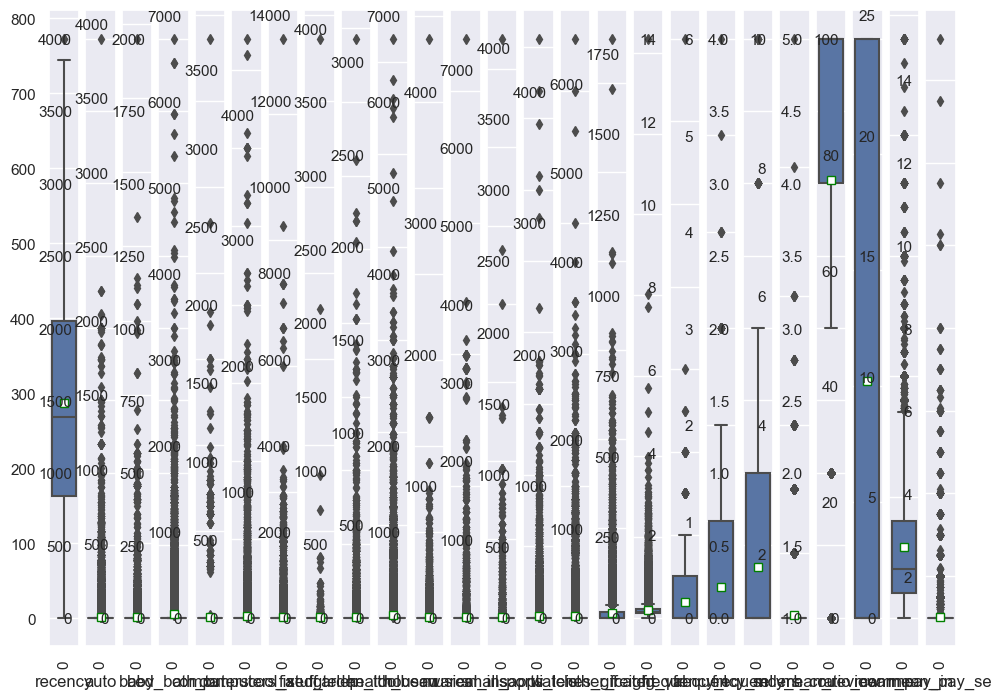

In [13]:
MVA.boxplot_nums(df, num_cols)

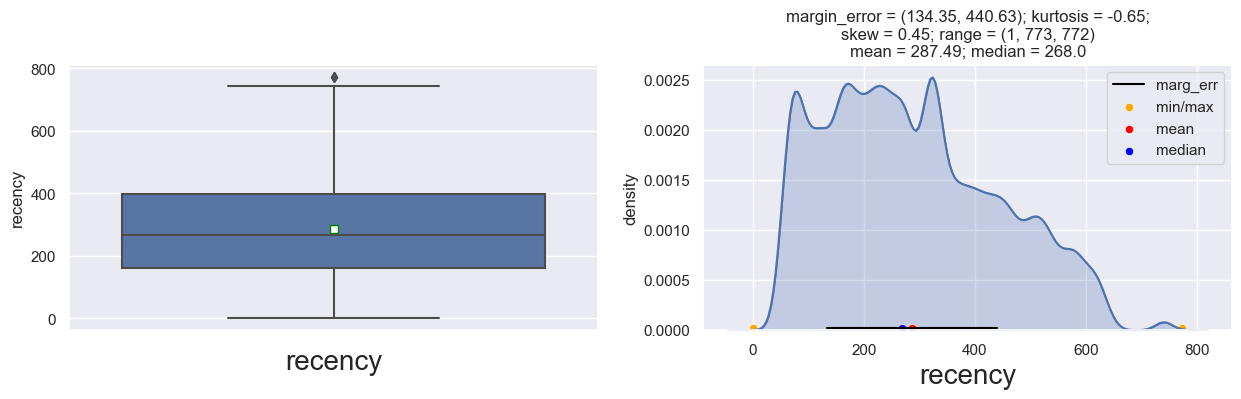

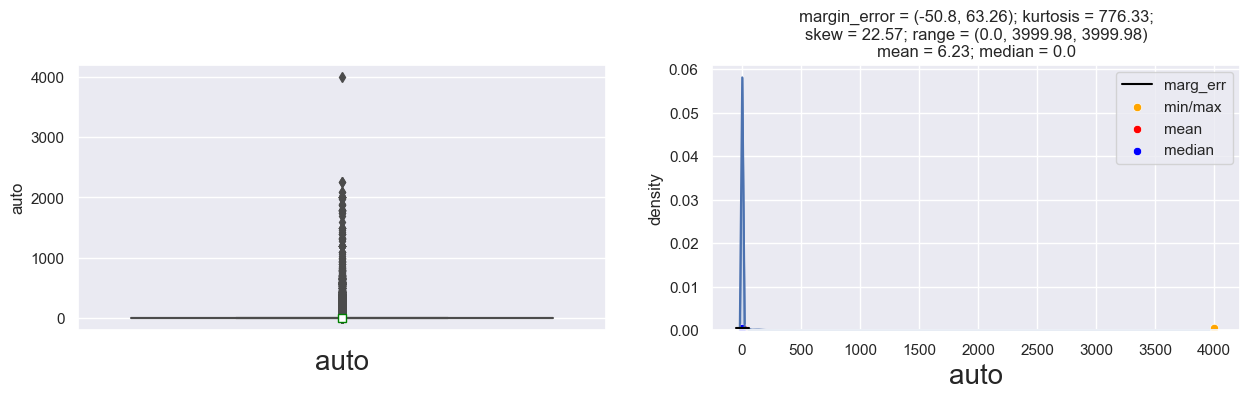

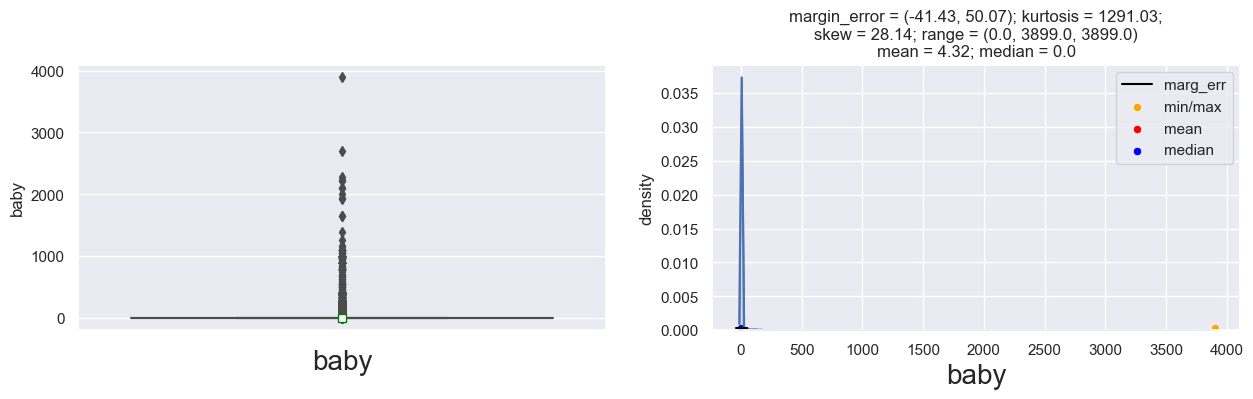

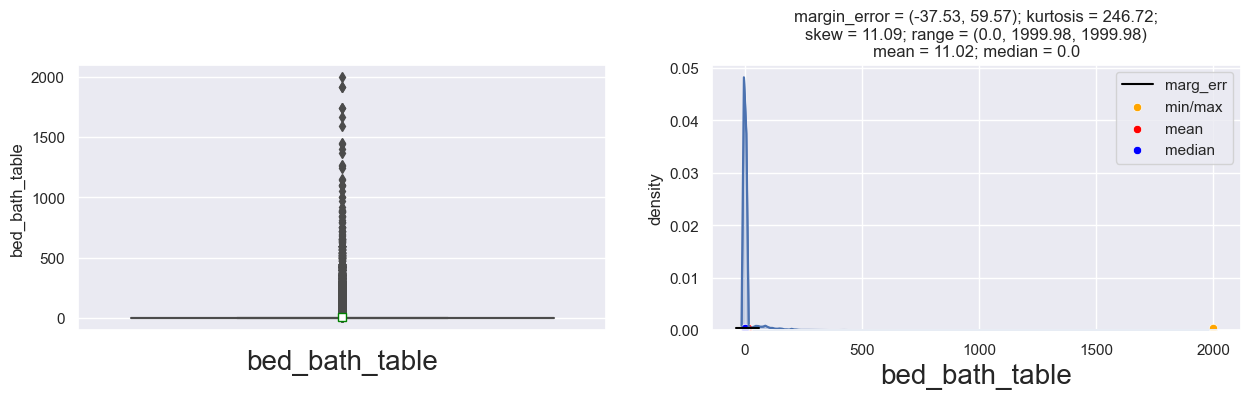

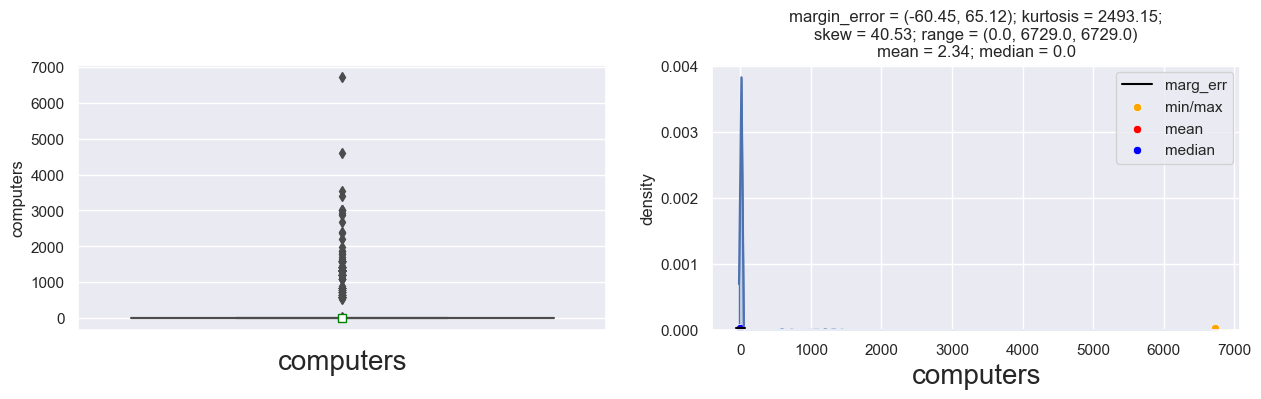

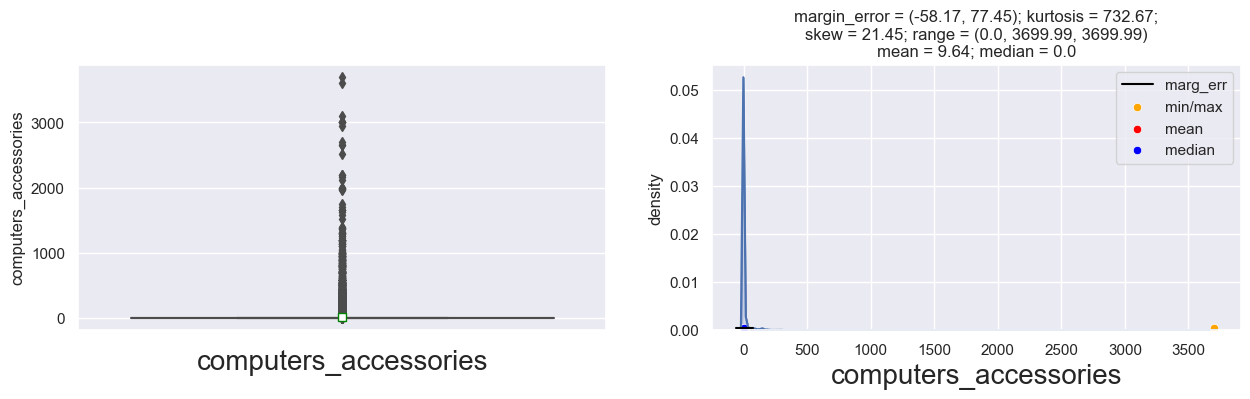

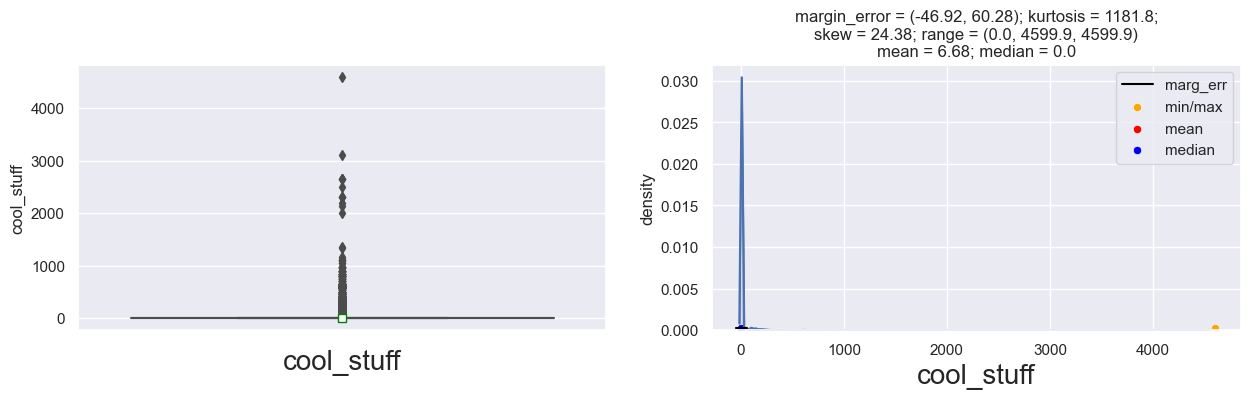

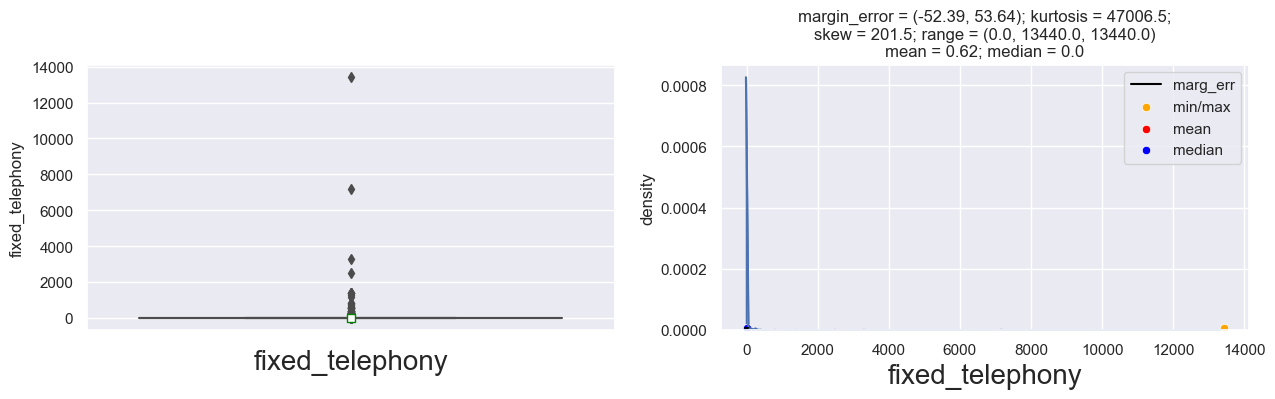

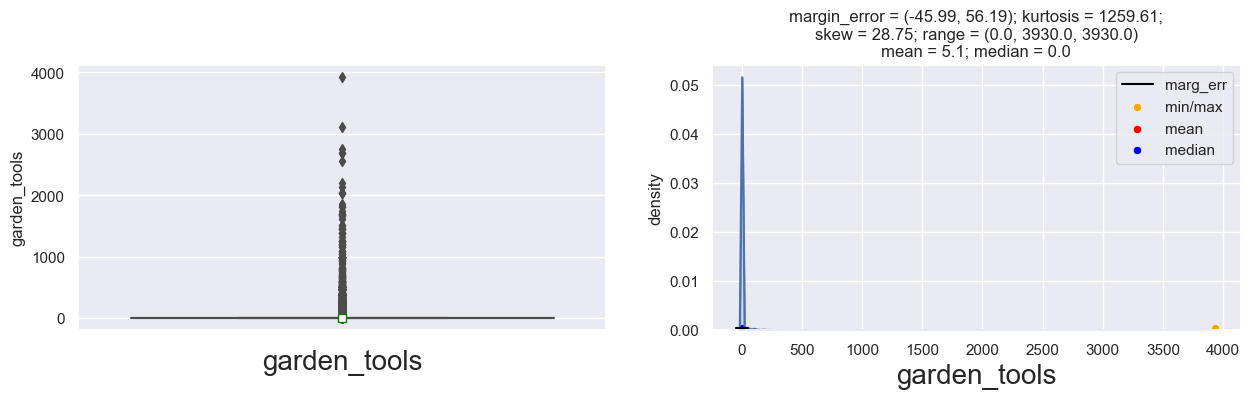

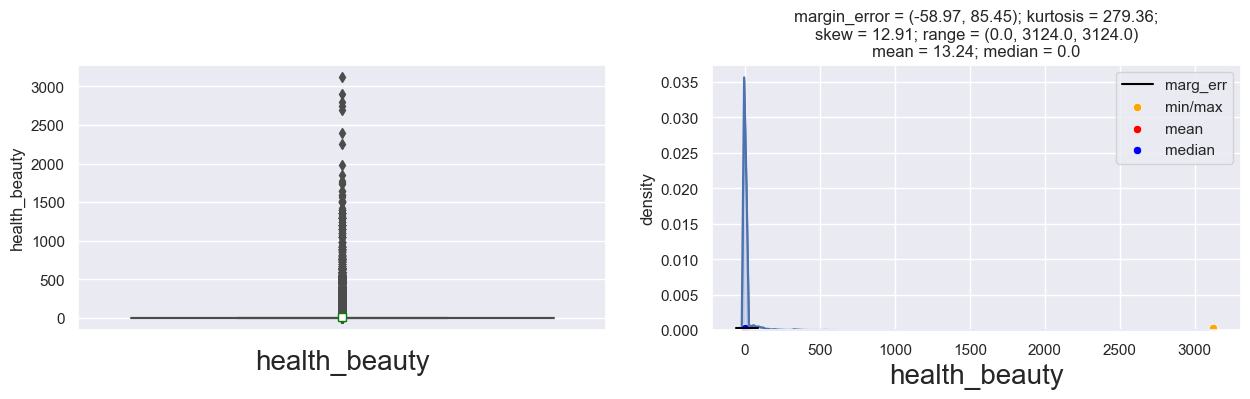

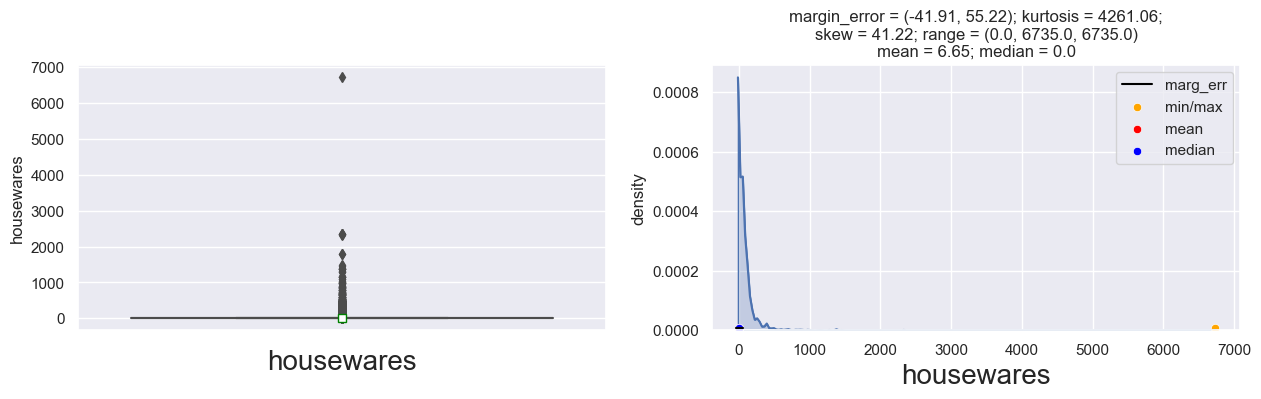

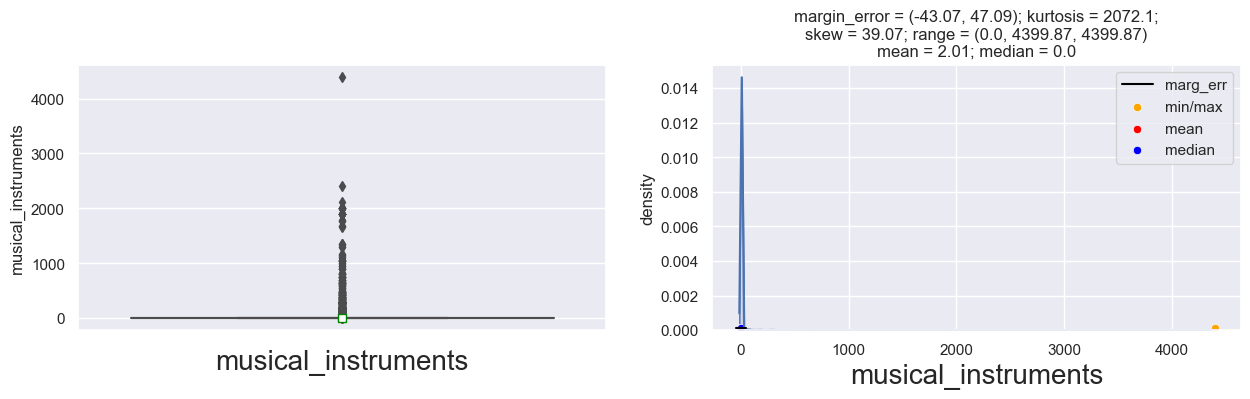

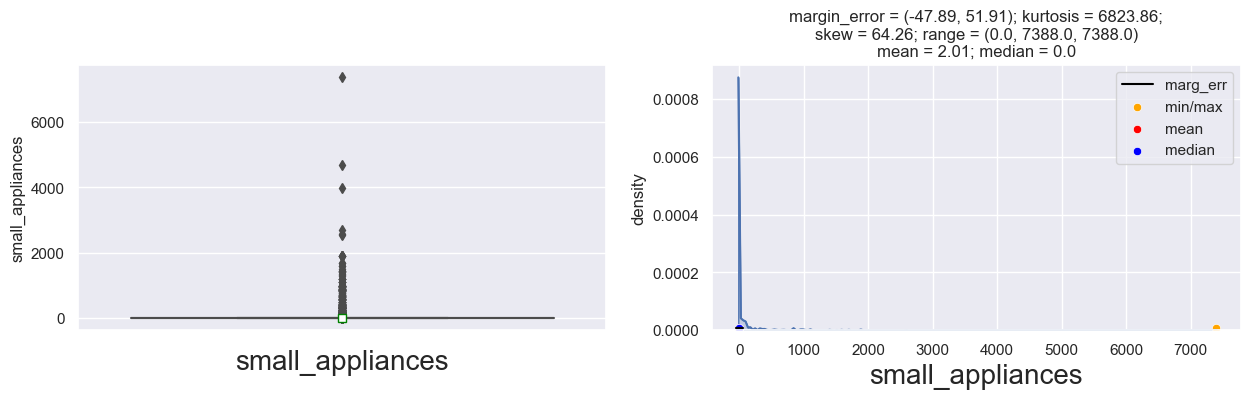

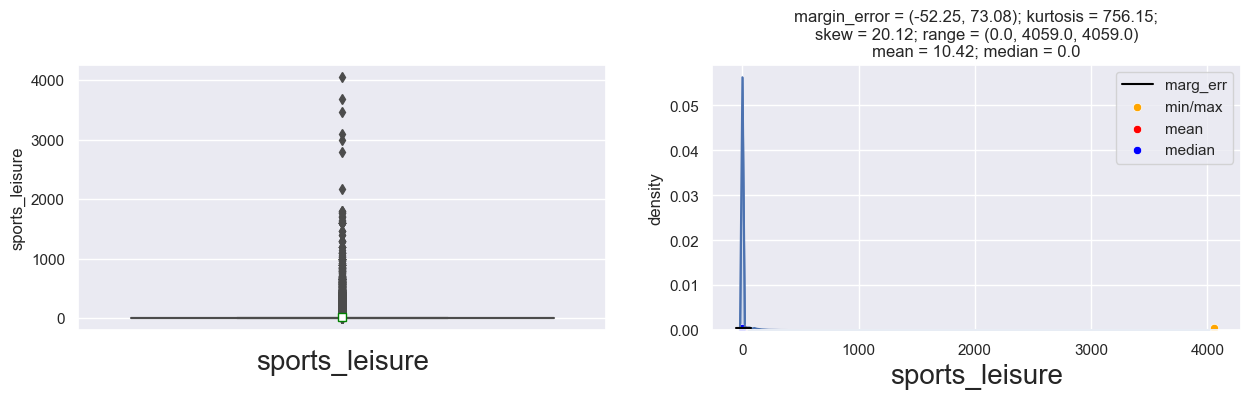

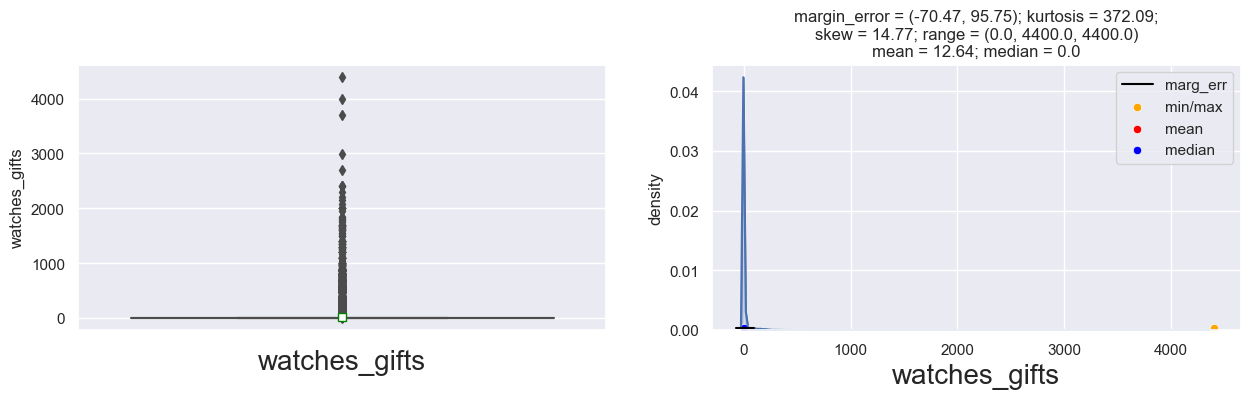

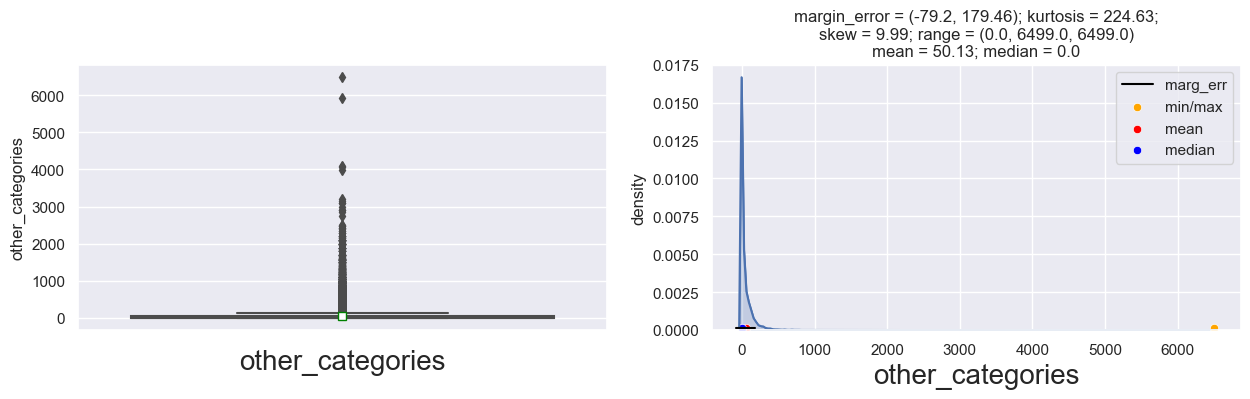

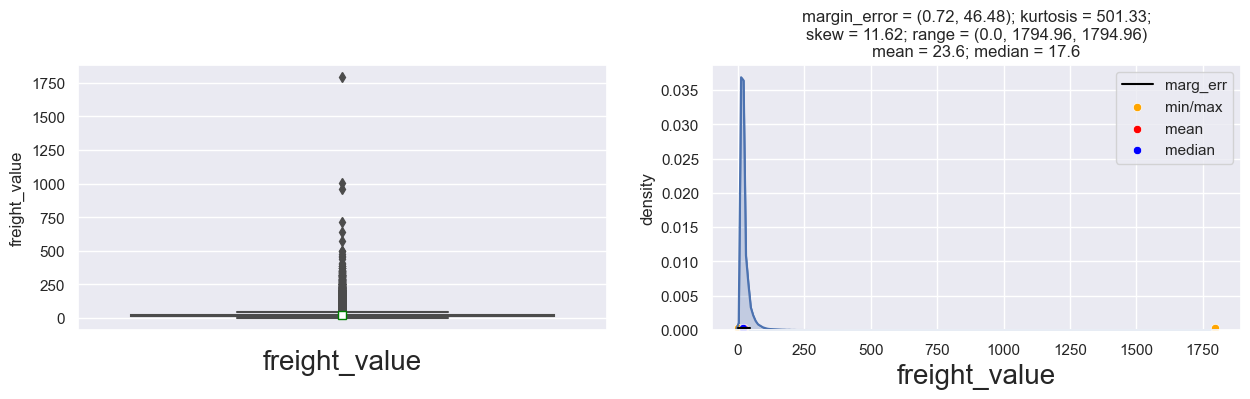

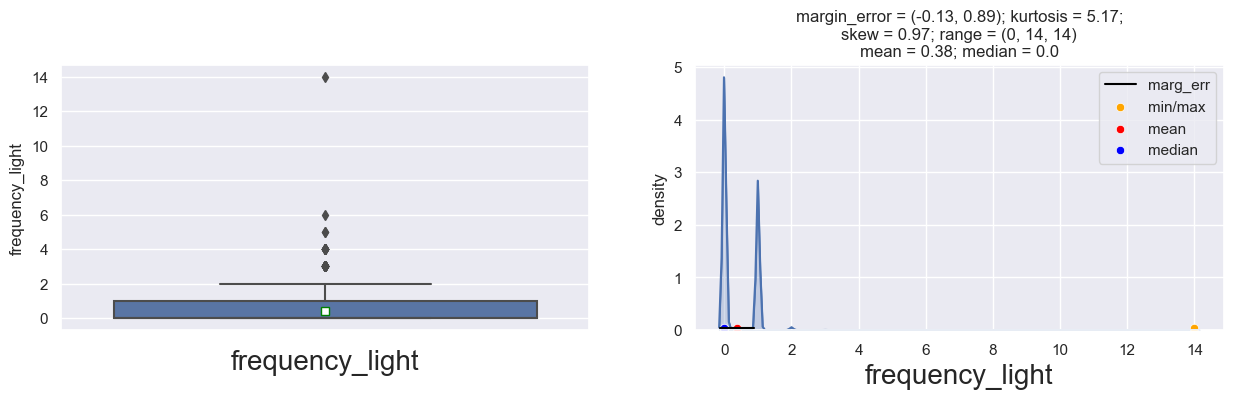

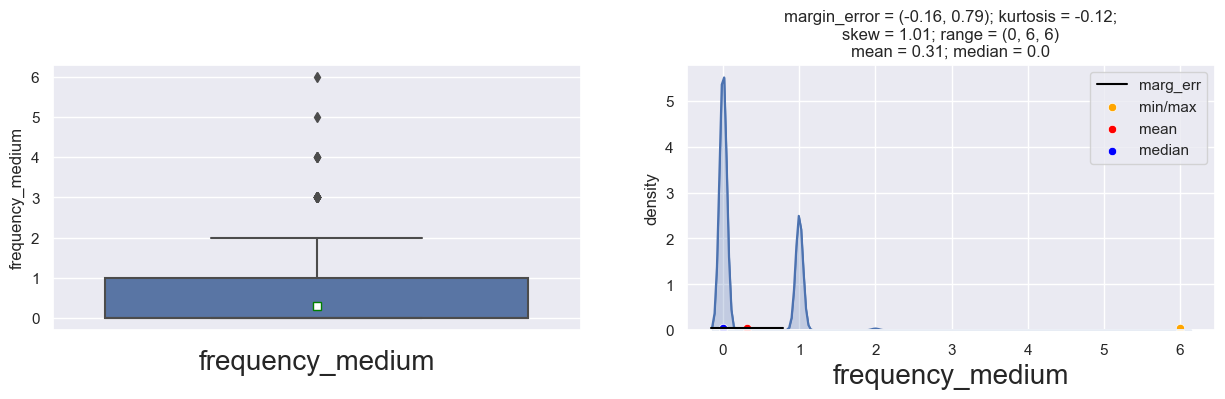

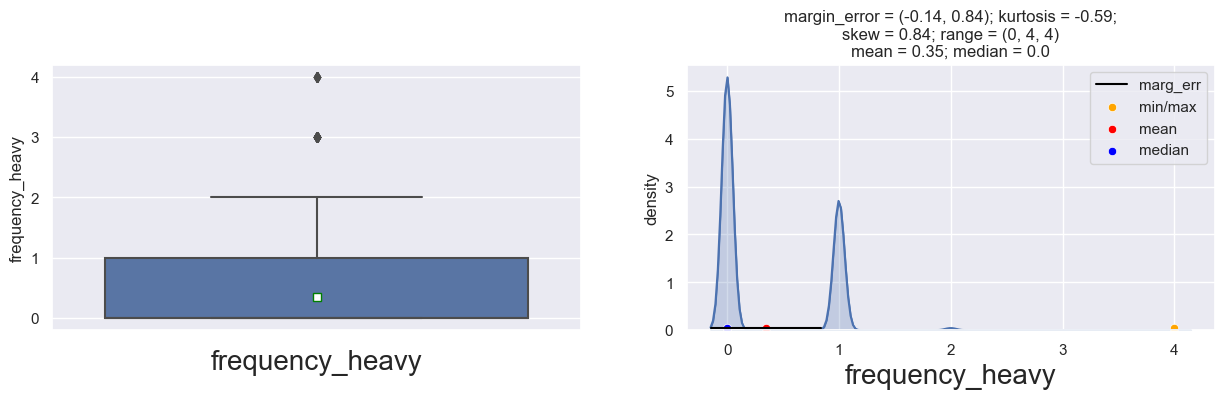

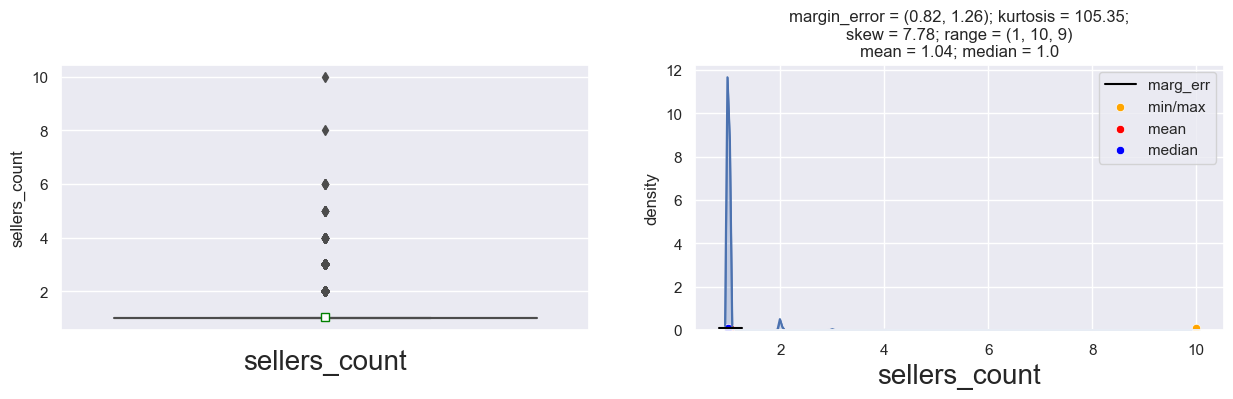

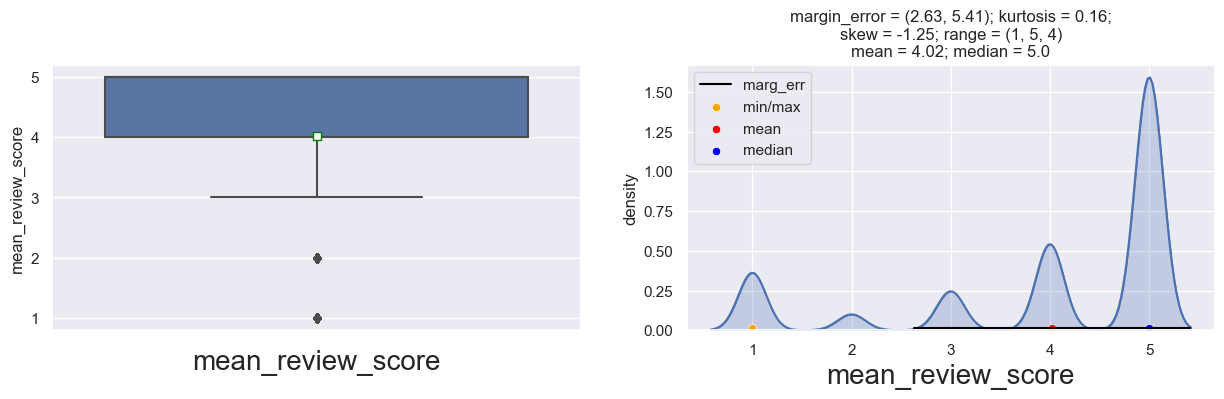

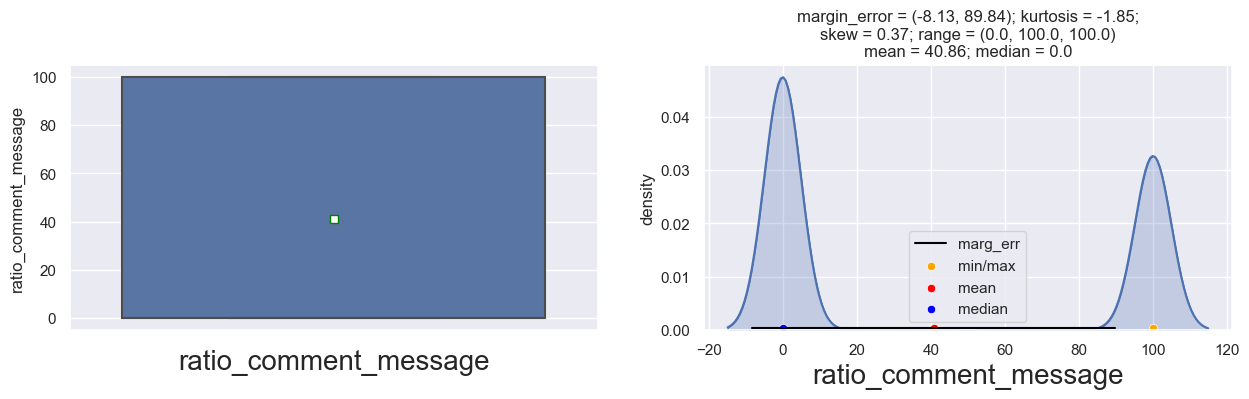

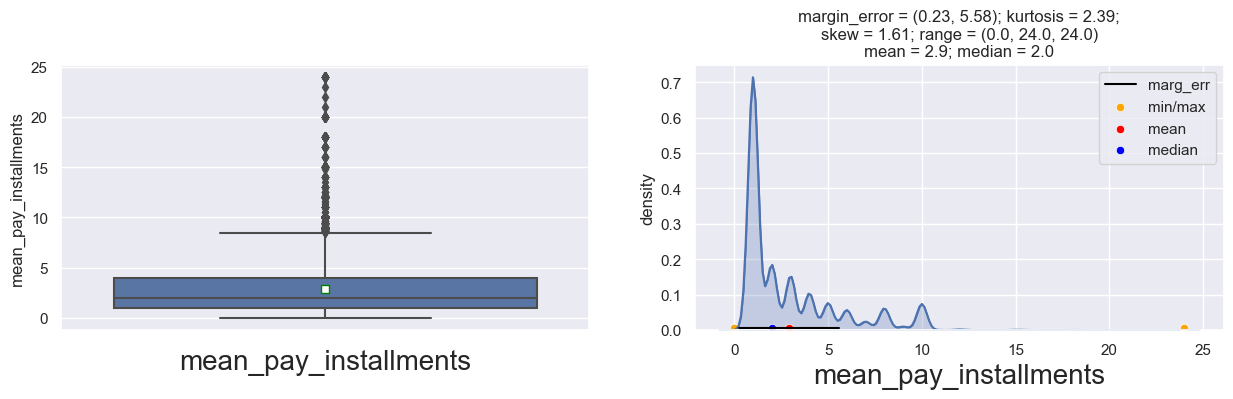

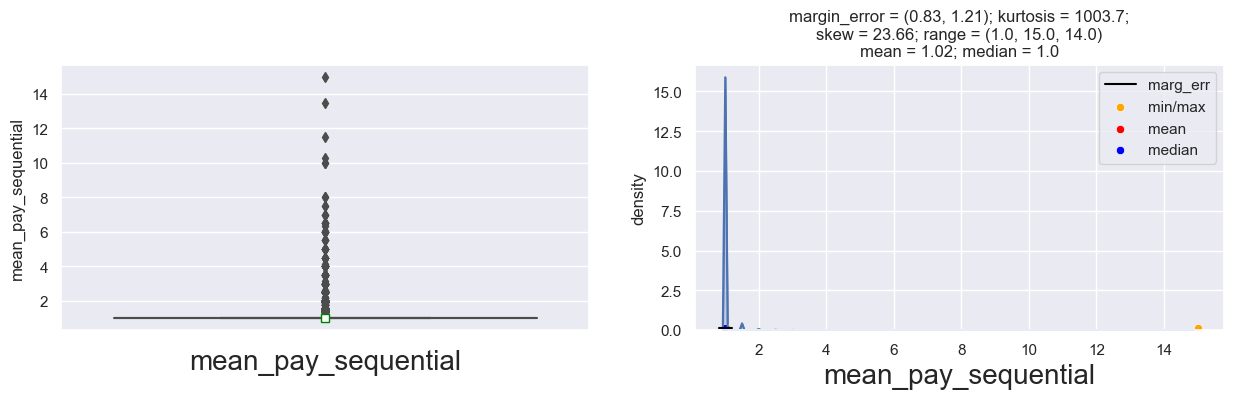

In [14]:
UVA.num_plus(df, num_cols)

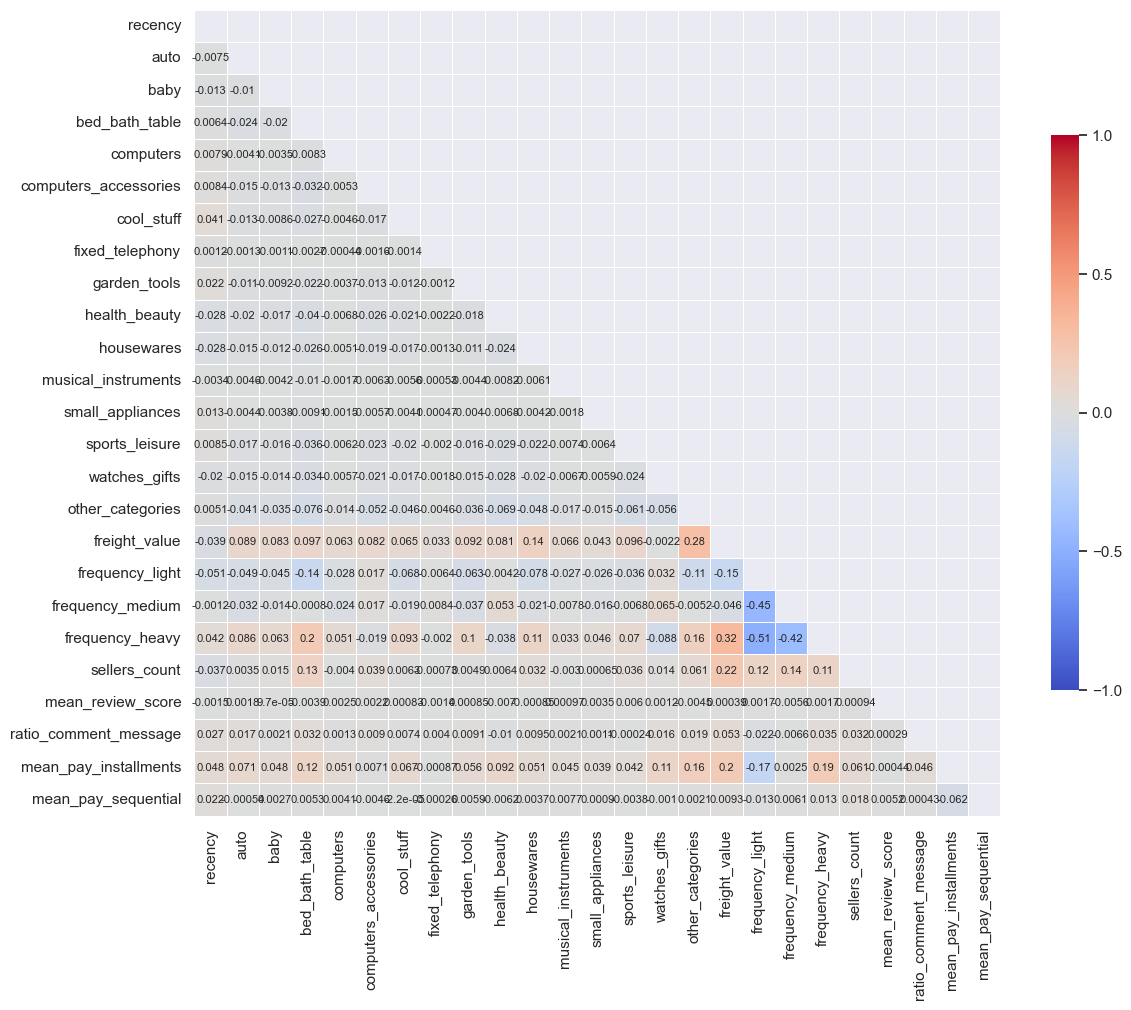

In [15]:
MVA.heatmap_num_2(df, annot_val=True, textsize=8) #

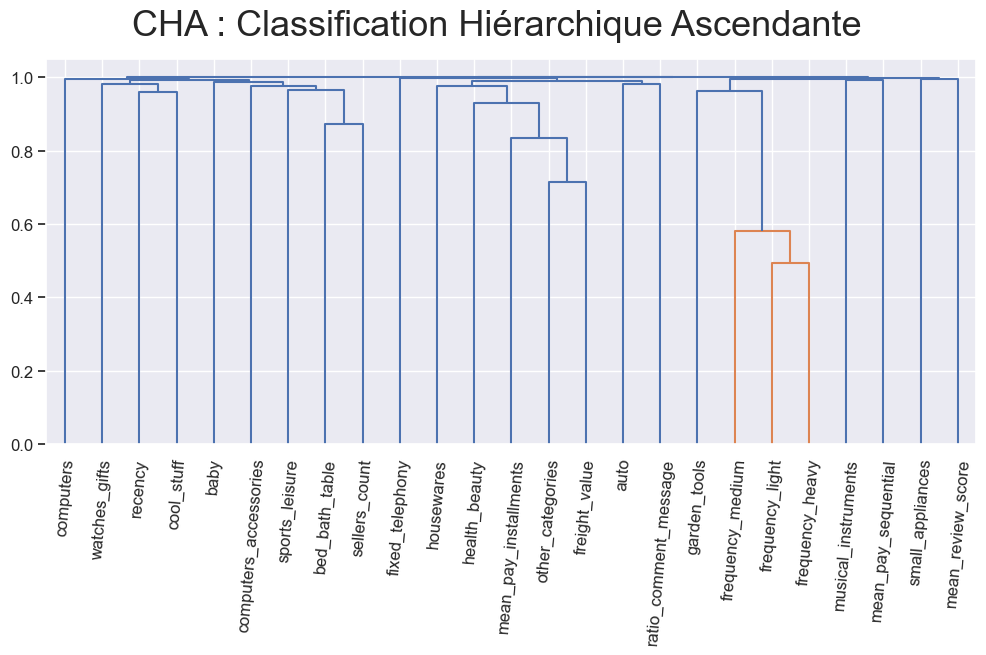

In [16]:
PCA.CHA(df, num_cols, label_size=12, rotation=85)

# Echantillon

In [17]:
df_redux = df.sample(10000, random_state=1).copy()
X = df_redux.copy()
#categorical_columns = X.select_dtypes(['category','object']).columns
num_cols = X.select_dtypes(include=np.number).columns.to_list()

ss = StandardScaler()
X[num_cols] = ss.fit_transform(X[num_cols])

,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,garden_tools,health_beauty,...,other_categories,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,ratio_comment_message,mean_pay_installments,mean_pay_sequential
78656,1.091647,-0.122724,-0.090324,-0.224284,-0.039644,-0.146394,-0.14893,-0.022392,1.029304,-0.185553,...,-0.405858,-0.480673,-0.755324,-0.65275,1.323486,-0.180227,0.698605,-0.838135,0.029723,-0.133036
79130,1.163737,-0.122724,0.450260,-0.224284,-0.039644,-0.146394,-0.14893,-0.022392,-0.103693,-0.185553,...,-0.405858,-0.403243,1.227153,-0.65275,-0.721456,-0.180227,-0.745391,1.201896,-0.339351,-0.133036
52003,-0.140445,-0.122724,-0.090324,0.661401,-0.039644,-0.146394,-0.14893,-0.022392,-0.103693,-0.185553,...,-0.405858,-0.683577,1.227153,-0.65275,-0.721456,-0.180227,-0.023393,1.201896,-0.708426,-0.133036
66882,-1.457735,-0.122724,-0.090324,-0.224284,-0.039644,-0.146394,-0.14893,-0.022392,-0.103693,-0.185553,...,0.401039,-0.541777,-0.755324,-0.65275,1.323486,-0.180227,-1.467389,-0.838135,-0.708426,-0.133036
59349,0.246222,-0.122724,-0.090324,-0.224284,-0.039644,-0.146394,-0.14893,-0.022392,-0.103693,-0.185553,...,-0.115382,-0.403243,1.227153,-0.65275,-0.721456,-0.180227,-0.745391,-0.838135,-0.708426,-0.133036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22453,1.045771,-0.122724,-0.090324,-0.224284,-0.039644,-0.146394,-0.14893,-0.022392,-0.103693,0.034543,...,-0.405858,-0.403243,1.227153,-0.65275,-0.721456,-0.180227,0.698605,-0.838135,-0.708426,-0.133036
76925,-1.326662,-0.122724,-0.090324,-0.224284,-0.039644,-0.146394,-0.14893,-0.022392,-0.103693,-0.185553,...,-0.353437,-0.740483,1.227153,-0.65275,-0.721456,-0.180227,0.698605,-0.838135,-0.708426,-0.133036
75590,1.596280,-0.122724,-0.090324,-0.224284,-0.039644,-0.146394,-0.14893,-0.022392,-0.103693,-0.185553,...,2.100028,0.794591,-0.755324,-0.65275,1.323486,-0.180227,0.698605,-0.838135,0.029723,-0.133036
59450,1.366901,-0.122724,-0.090324,-0.224284,-0.039644,1.305865,-0.14893,-0.022392,-0.103693,-0.185553,...,-0.405858,-0.123842,-0.755324,-0.65275,1.323486,-0.180227,0.698605,-0.838135,1.506021,-0.133036


### X_std / echantillon

In [22]:
X_std = PCA.clean_data(df, num_cols, impute=False, std=True)

	>>> Selected features: ['recency', 'auto', 'baby', 'bed_bath_table', 'computers', 'computers_accessories', 'cool_stuff', 'fixed_telephony', 'garden_tools', 'health_beauty', 'housewares', 'musical_instruments', 'small_appliances', 'sports_leisure', 'watches_gifts', 'other_categories', 'freight_value', 'frequency_light', 'frequency_medium', 'frequency_heavy', 'sellers_count', 'mean_review_score', 'ratio_comment_message', 'mean_pay_installments', 'mean_pay_sequential']
	>>> Standardized data


In [23]:
X_std

,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,garden_tools,health_beauty,...,other_categories,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,ratio_comment_message,mean_pay_installments,mean_pay_sequential
0,0.604081,-0.109247,0.679080,-0.226909,-0.037226,-0.142170,-0.124617,-0.011788,-0.099809,-0.183339,...,-0.387629,-0.269261,1.220451,1.440315,-0.711205,4.432184,-0.015643,1.207351,-0.710769,3.811199
1,-1.322254,-0.109247,-0.094418,-0.226909,-0.037226,-0.142170,-0.124617,-0.011788,-0.099809,-0.183339,...,0.530175,-0.036748,1.220451,-0.658266,-0.711205,-0.175118,-0.015643,1.207351,-0.710769,-0.120716
2,-1.420203,2.694563,-0.094418,-0.226909,-0.037226,-0.142170,-0.124617,-0.011788,-0.099809,-0.183339,...,-0.387629,-0.191465,-0.752066,1.440315,-0.711205,-0.175118,0.703556,-0.834066,0.036052,-0.120716
3,0.297174,-0.109247,-0.094418,-0.226909,-0.037226,-0.142170,-0.124617,-0.011788,-0.099809,-0.183339,...,-0.039683,0.157305,-0.752066,1.440315,-0.711205,-0.175118,-0.734842,1.207351,-0.710769,-0.120716
4,-0.270932,-0.109247,-0.094418,-0.226909,-0.037226,-0.142170,-0.124617,-0.011788,-0.099809,-0.183339,...,-0.233760,-0.650373,1.220451,-0.658266,-0.711205,-0.175118,0.703556,-0.834066,-0.710769,-0.120716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95394,1.955780,-0.109247,-0.094418,-0.226909,-0.037226,-0.142170,-0.124617,-0.011788,-0.099809,0.813732,...,-0.387629,-0.459817,-0.752066,1.440315,-0.711205,-0.175118,-2.173241,-0.834066,0.036052,-0.120716
95395,-0.225222,-0.109247,3.728269,-0.226909,-0.037226,-0.142170,-0.124617,-0.011788,-0.099809,-0.183339,...,-0.387629,-0.153005,-0.752066,-0.658266,1.324691,-0.175118,0.703556,1.207351,0.036052,-0.120716
95396,0.839159,-0.109247,-0.094418,-0.226909,-0.037226,-0.142170,-0.124617,-0.011788,-0.099809,-0.183339,...,1.205112,1.810248,-0.752066,-0.658266,1.324691,-0.175118,0.703556,1.207351,0.782873,-0.120716
95397,-0.035854,-0.109247,-0.094418,-0.226909,-0.037226,5.166825,-0.124617,-0.011788,-0.099809,-0.183339,...,-0.387629,2.516530,-0.752066,-0.658266,1.324691,-0.175118,0.703556,1.207351,0.409463,-0.120716


# PCA

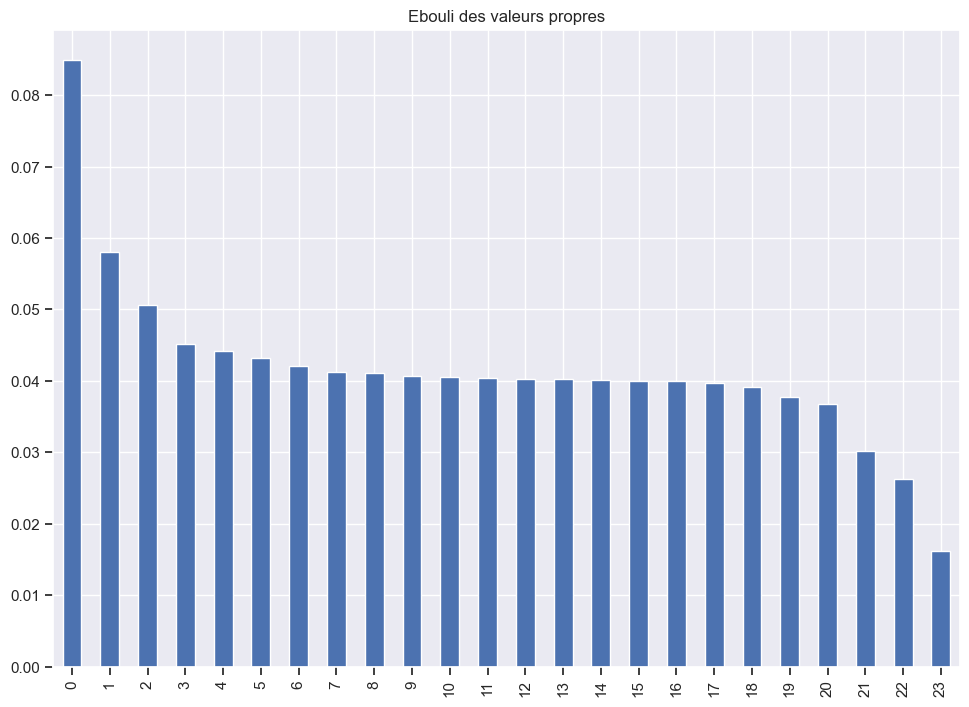

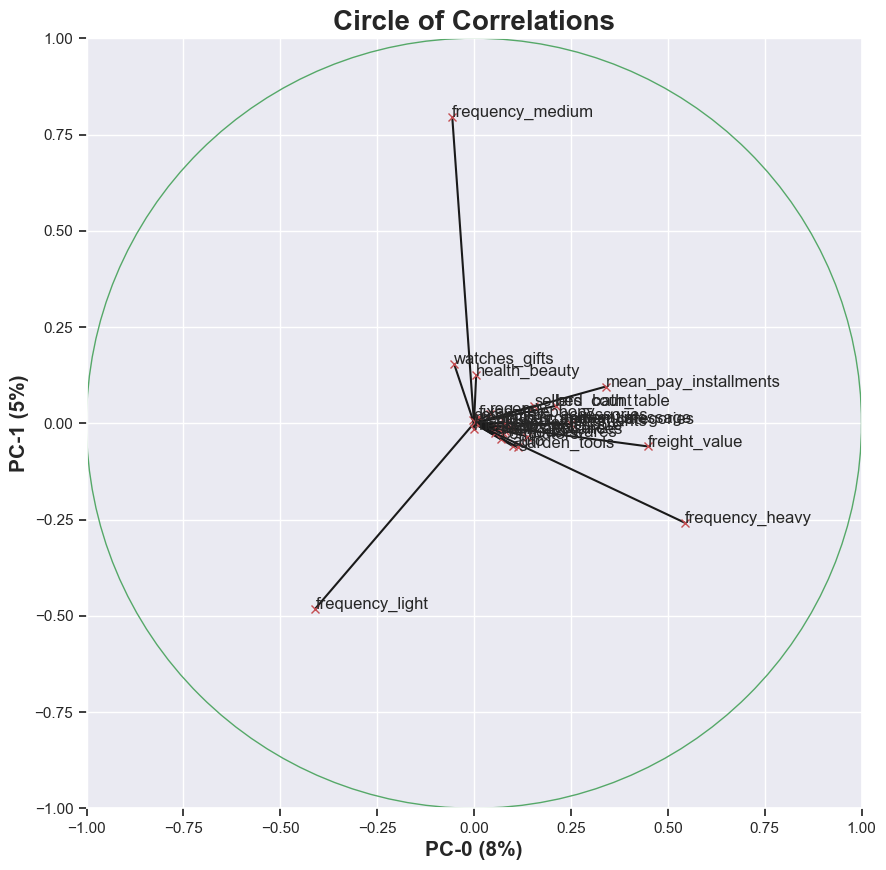

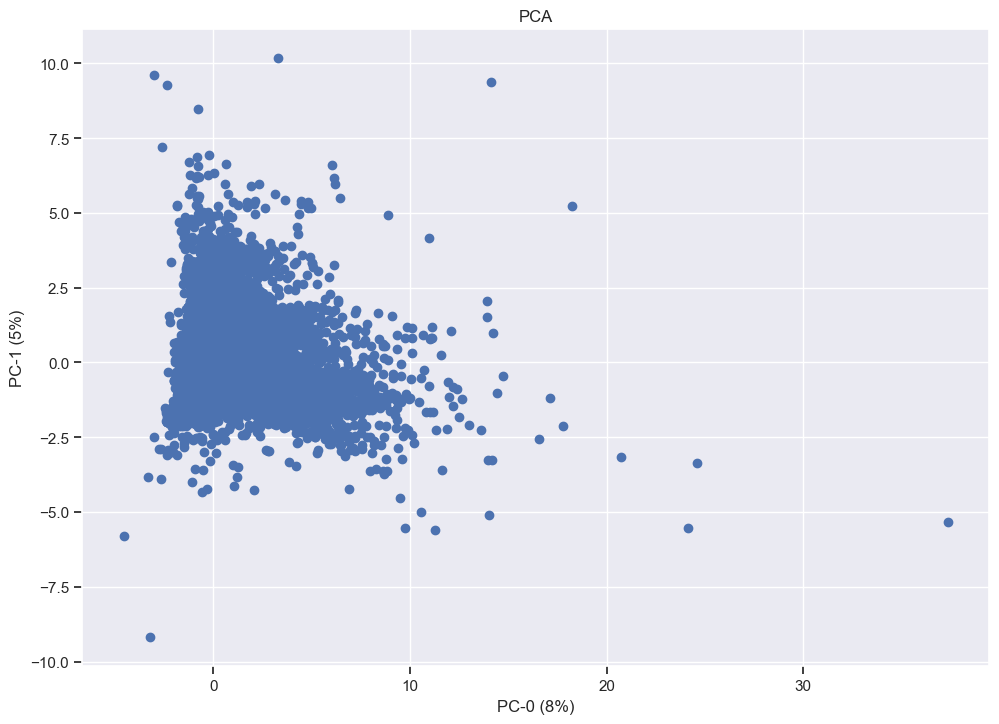

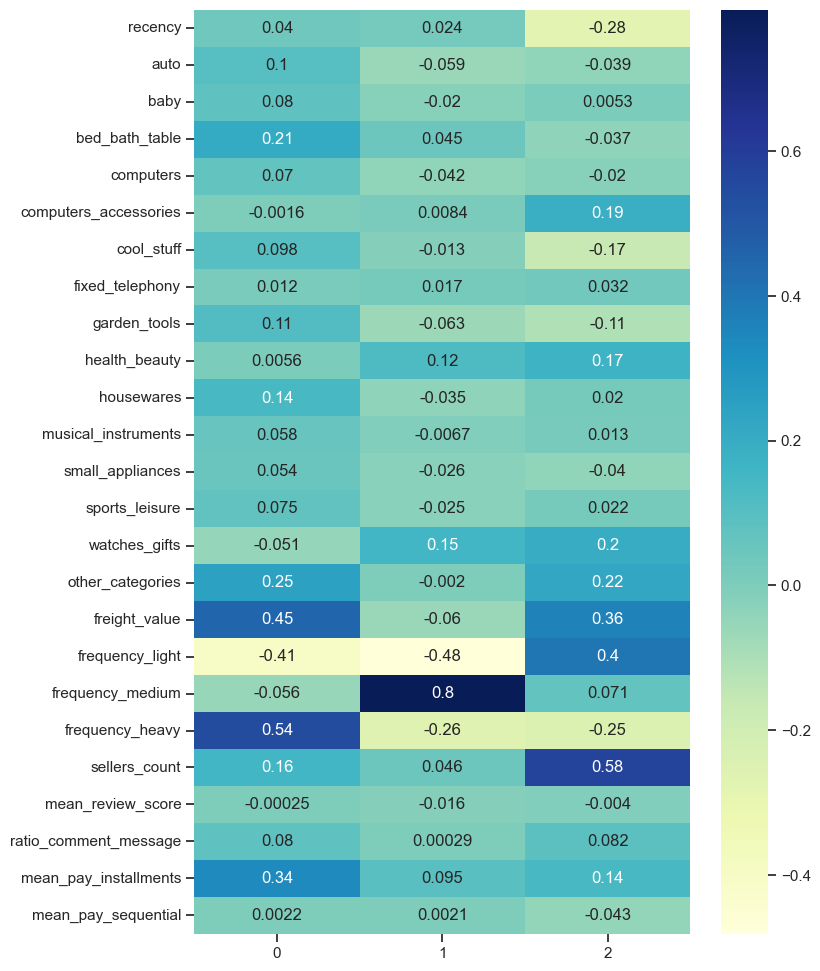

Résumé PCA
Total: 24 composants
----------------------------------------
Moyenne de la variance expliquée : 0.042
----------------------------------------
    explained variance  cumulative
1             0.084885    0.084885
2             0.058062    0.142946
3             0.050628    0.193575
4             0.045101    0.238675
5             0.044234    0.282910
6             0.043200    0.326109
7             0.042021    0.368130
8             0.041290    0.409420
9             0.041111    0.450530
10            0.040621    0.491152
11            0.040554    0.531706
12            0.040461    0.572167
13            0.040288    0.612455
14            0.040199    0.652653
15            0.040063    0.692716
16            0.040042    0.732758
17            0.040009    0.772767
18            0.039758    0.812524
19            0.039144    0.851669
20            0.037727    0.889396
----------------------------------------


,PC-0,PC-1,PC-2,PC-3,PC-4,PC-5,PC-6,PC-7,PC-8,PC-9,...,PC-14,PC-15,PC-16,PC-17,PC-18,PC-19,PC-20,PC-21,PC-22,PC-23
recency,0.040479,0.023631,-0.281222,0.074295,-0.103313,-0.467335,0.292856,-0.143469,-0.027321,-0.045981,...,0.009770,0.034578,-0.017268,-0.095107,0.176864,-0.423670,0.553900,0.170663,0.110801,0.006957
auto,0.099866,-0.058886,-0.038738,0.071795,-0.172802,0.155876,0.005123,0.236807,-0.074341,0.667294,...,0.075872,0.018848,-0.243069,-0.142929,-0.235229,0.037403,0.233699,-0.025948,0.067926,-0.192836
baby,0.080431,-0.019888,0.005313,-0.009438,-0.025357,0.209988,0.030042,0.088645,-0.035911,-0.143773,...,0.054829,0.089345,-0.008583,-0.098462,0.210999,-0.046639,0.148474,-0.042713,0.040439,-0.165191
bed_bath_table,0.210881,0.044898,-0.036941,-0.585234,-0.224122,-0.193044,-0.402501,-0.177744,-0.042689,-0.001963,...,-0.044817,0.027240,0.111453,0.103476,-0.027339,-0.094863,-0.056075,-0.187643,0.392769,-0.290436
computers,0.069748,-0.041949,-0.020041,0.104736,-0.111890,0.044239,0.097056,-0.033985,-0.004792,-0.182936,...,-0.745168,0.250750,-0.067443,-0.141942,-0.009011,0.280086,0.112204,0.007643,0.008169,-0.106024
computers_accessories,-0.001574,0.008357,0.187737,-0.138366,0.060305,-0.082054,0.547762,0.000872,-0.362804,0.280636,...,-0.113751,-0.146199,0.177131,0.025552,-0.087755,-0.271948,-0.338663,-0.035806,-0.046876,-0.177212
cool_stuff,0.098047,-0.012848,-0.167147,0.050954,-0.182011,-0.129433,0.275885,-0.161258,-0.103881,-0.091657,...,0.045357,-0.093851,-0.195002,0.107973,-0.269282,0.335953,-0.066765,-0.079493,0.108258,-0.184275
fixed_telephony,0.011903,0.017339,0.031567,0.008663,0.044416,0.028756,0.122455,0.042486,-0.062803,0.060280,...,-0.040783,0.753599,0.373810,0.324263,-0.098760,-0.073651,-0.014353,-0.020925,-0.055508,-0.037016
garden_tools,0.113701,-0.062885,-0.110783,0.031647,-0.076640,0.026117,0.214335,0.045483,-0.160401,-0.260789,...,0.078143,-0.111990,-0.080370,0.136762,-0.198615,0.285424,0.107173,-0.109730,0.060592,-0.183183
health_beauty,0.005558,0.124141,0.170706,0.171715,-0.218630,0.418832,0.007338,-0.580257,-0.192530,-0.078490,...,0.089077,0.049516,-0.210075,0.017905,0.242691,-0.184991,-0.116633,0.222368,-0.003240,-0.237804


In [45]:
PCA.myPCA(X_std)

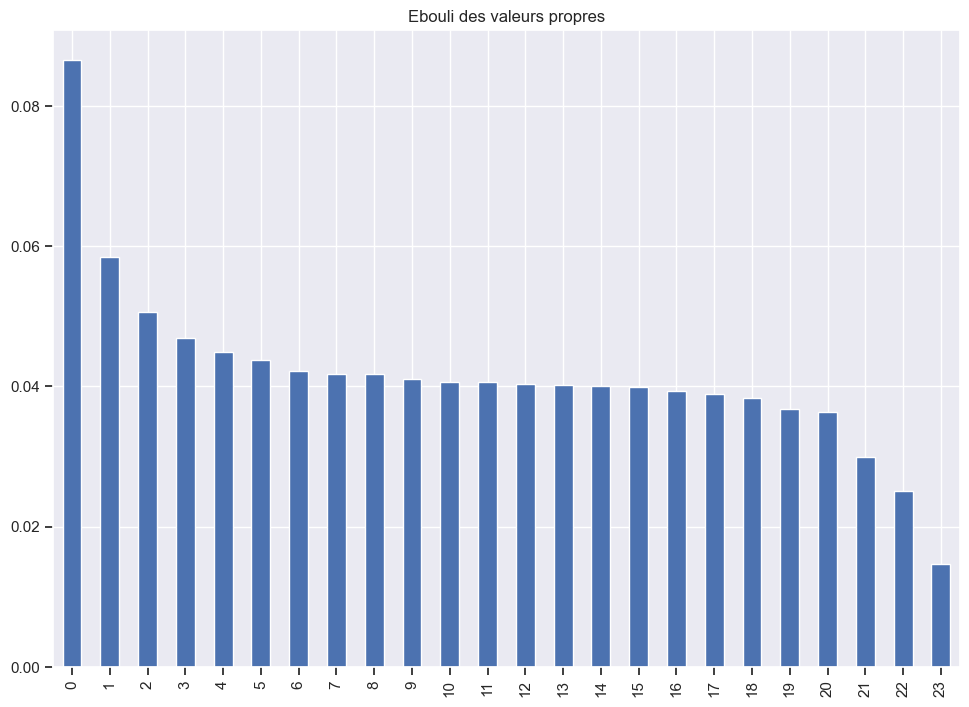

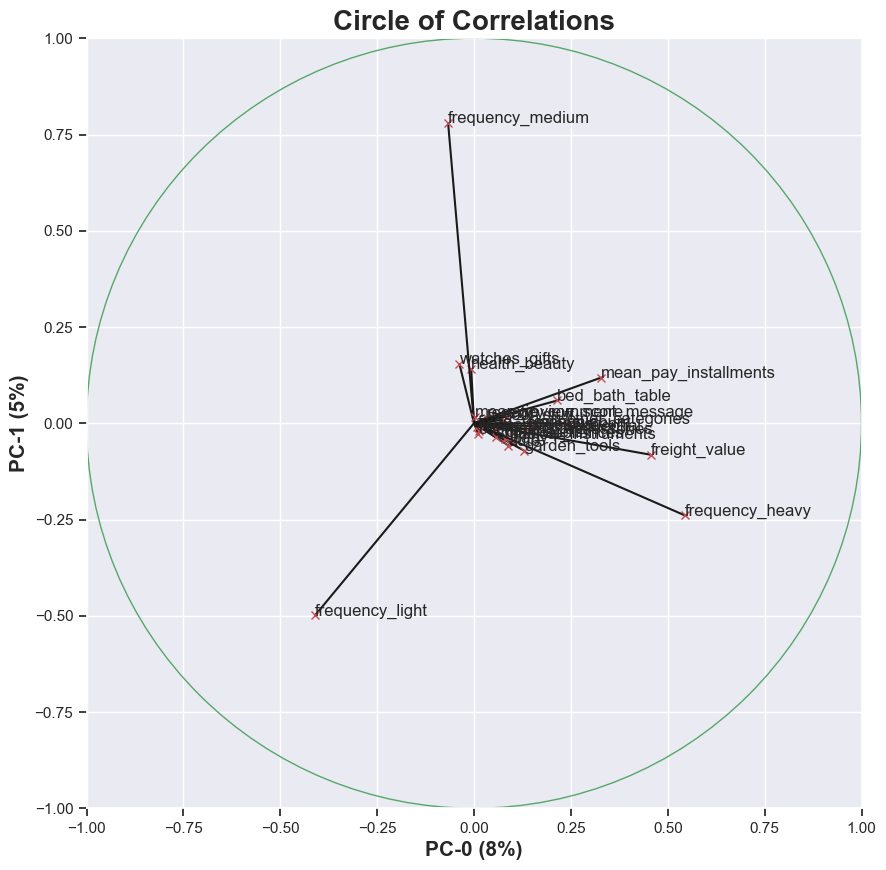

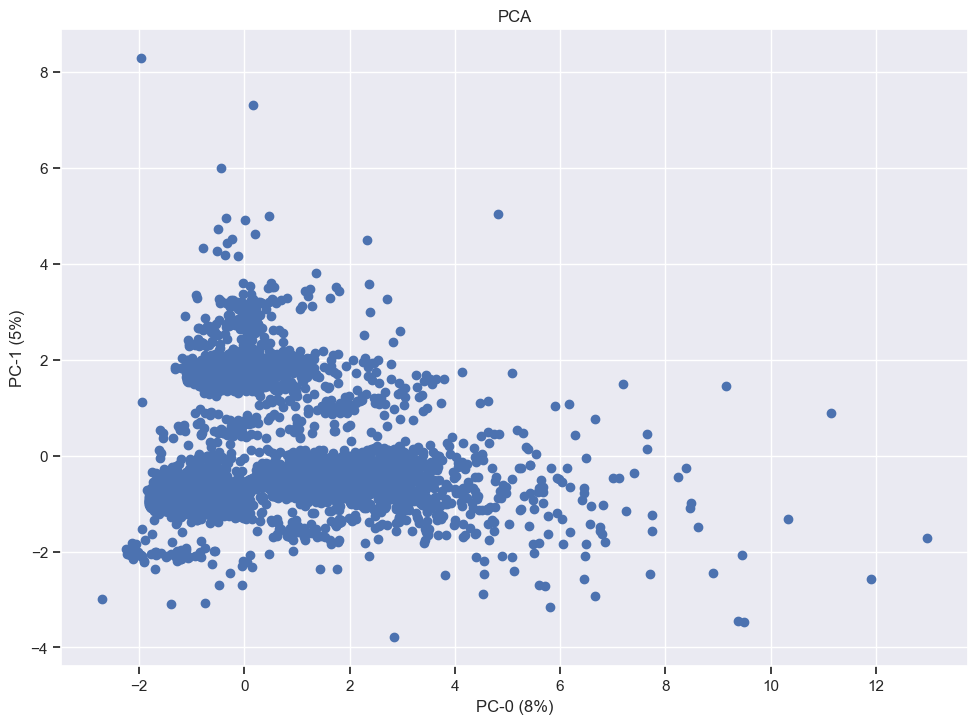

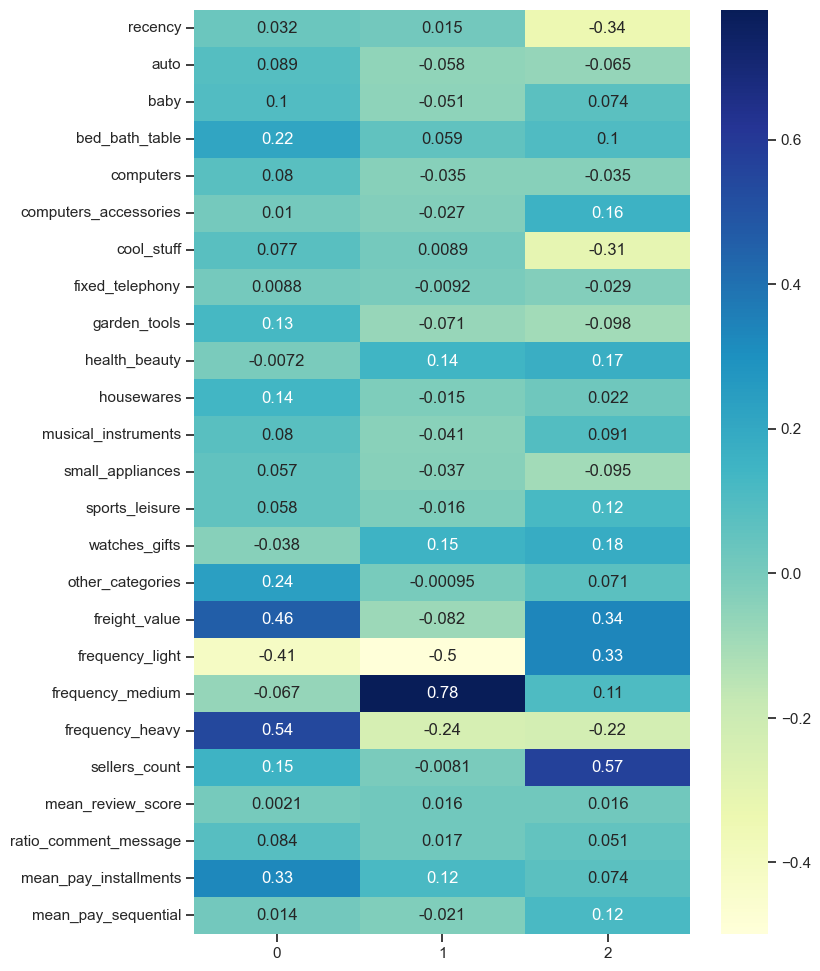

Résumé PCA
Total: 24 composants
----------------------------------------
Moyenne de la variance expliquée : 0.042
----------------------------------------
    explained variance  cumulative
1             0.086545    0.086545
2             0.058430    0.144975
3             0.050543    0.195518
4             0.046906    0.242424
5             0.044838    0.287262
6             0.043777    0.331040
7             0.042205    0.373245
8             0.041726    0.414971
9             0.041701    0.456672
10            0.041042    0.497714
11            0.040677    0.538391
12            0.040575    0.578966
13            0.040364    0.619330
14            0.040196    0.659526
15            0.040116    0.699642
16            0.039871    0.739513
17            0.039382    0.778895
18            0.038932    0.817827
19            0.038393    0.856220
20            0.036790    0.893010
----------------------------------------


,PC-0,PC-1,PC-2,PC-3,PC-4,PC-5,PC-6,PC-7,PC-8,PC-9,...,PC-14,PC-15,PC-16,PC-17,PC-18,PC-19,PC-20,PC-21,PC-22,PC-23
recency,0.032310,0.014918,-0.343130,-0.037109,-0.114774,-0.371214,0.302944,0.094799,-0.025720,0.157695,...,-0.043550,-0.003378,-0.002222,0.363692,0.000609,-0.442856,-0.473143,0.197980,0.084269,-0.034653
auto,0.088817,-0.057842,-0.064991,0.003486,-0.144402,0.187191,-0.182492,-0.080668,0.055226,-0.453472,...,-0.077788,-0.004703,0.079571,0.220305,0.235181,0.006365,-0.191646,-0.031662,0.113915,0.178206
baby,0.099688,-0.051065,0.073713,0.075826,0.083808,0.358397,0.149557,-0.131700,0.177849,-0.101895,...,0.040792,-0.182977,-0.072935,0.191389,-0.000949,-0.094928,-0.165718,-0.089782,-0.101007,0.205641
bed_bath_table,0.215044,0.059105,0.104066,-0.524944,-0.232010,-0.252811,-0.257781,-0.170694,-0.065589,0.031257,...,0.115147,-0.129608,0.066506,-0.171886,-0.141484,-0.213166,0.070164,-0.192814,0.385783,0.289692
computers,0.079799,-0.034672,-0.035391,0.131691,-0.182119,0.006422,-0.084765,0.294154,0.028450,0.194278,...,-0.493009,-0.038996,0.467853,-0.142063,-0.151839,0.258746,-0.174015,0.067970,0.037670,0.112848
computers_accessories,0.010219,-0.027200,0.158885,0.047645,-0.079848,0.048303,0.457522,-0.217423,0.101138,0.496911,...,0.017088,-0.064851,-0.163709,-0.098692,0.022713,-0.090431,0.260122,0.048720,-0.042377,0.193373
cool_stuff,0.077014,0.008938,-0.308403,-0.087878,-0.180774,0.018382,0.325143,-0.195687,0.035750,-0.136907,...,-0.009243,0.180717,0.004430,-0.072684,0.572146,0.263707,0.051109,-0.099828,0.143190,0.170889
fixed_telephony,0.008789,-0.009207,-0.029235,-0.006972,0.039096,0.056400,-0.083998,0.076248,-0.026521,0.120314,...,0.353312,0.805089,0.110843,0.133392,-0.103095,0.030631,-0.027864,-0.037070,-0.001297,0.030169
garden_tools,0.129526,-0.071293,-0.097626,-0.019219,-0.077243,0.050554,0.158751,0.107463,-0.059589,0.283720,...,-0.118896,0.041728,0.125315,-0.074904,0.080844,0.254142,-0.045355,-0.150475,0.048168,0.195876
health_beauty,-0.007154,0.140762,0.174521,0.168381,-0.261523,0.298894,-0.175178,-0.204204,-0.481764,0.138604,...,-0.219054,0.130882,0.052313,0.324683,0.046244,-0.221787,0.190553,0.243583,0.031180,0.210783


In [44]:
PCA.myPCA(X)

In [28]:
#MVA.heatmap_num_2(X_enc)

In [96]:
#num_cols_Xenc = X_enc.select_dtypes(include=np.number).columns.to_list()

In [29]:
#PCA.CHA(X_enc, num_cols_Xenc)

# K-Means

In [38]:
# print avancement au fur et à mesure

### Elbow method

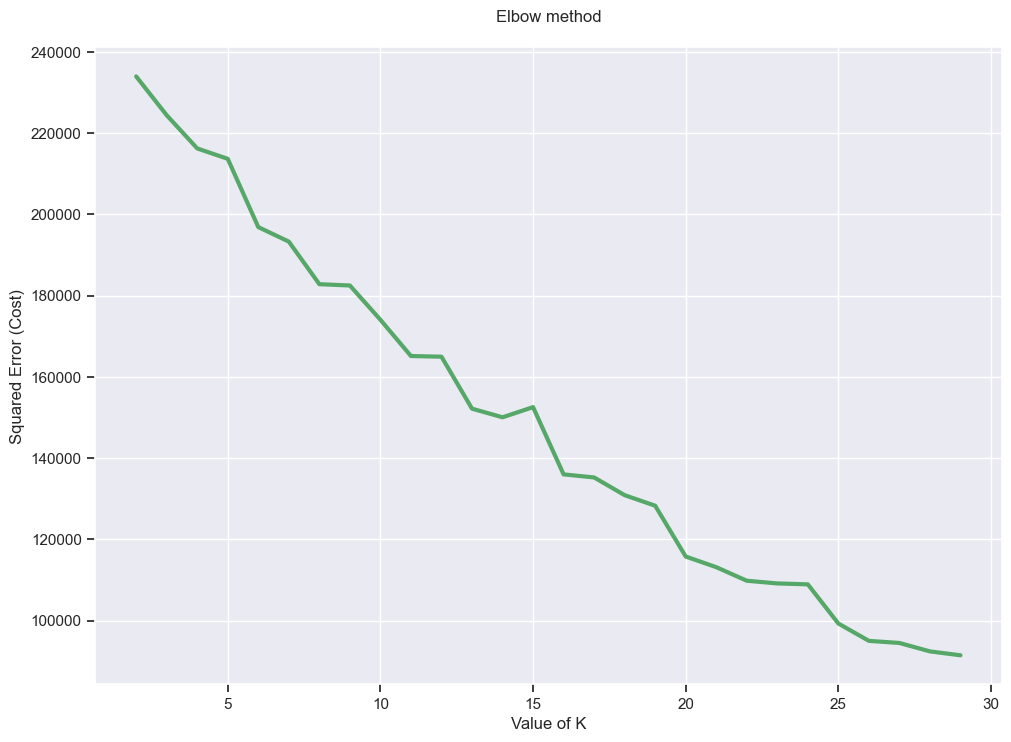

In [46]:
cost =[]
test_clusters = [i for i in range(2, 30)]
for i in test_clusters:
    #cls=KMeans(n_clusters=i,n_init=50,init='k-means++')
    cls = KMeans(n_clusters=i)
    cls.fit(X)
    cost.append(cls.inertia_)    


plt.plot(test_clusters, cost, color ='g', linewidth ='3')
plt.title("Elbow method\n")
plt.xlabel("Value of K")
plt.ylabel("Squared Error (Cost)")
#plt.axvline(x=nb_groupes_de_points, ymin=0, ymax=1, color="red")
plt.show()

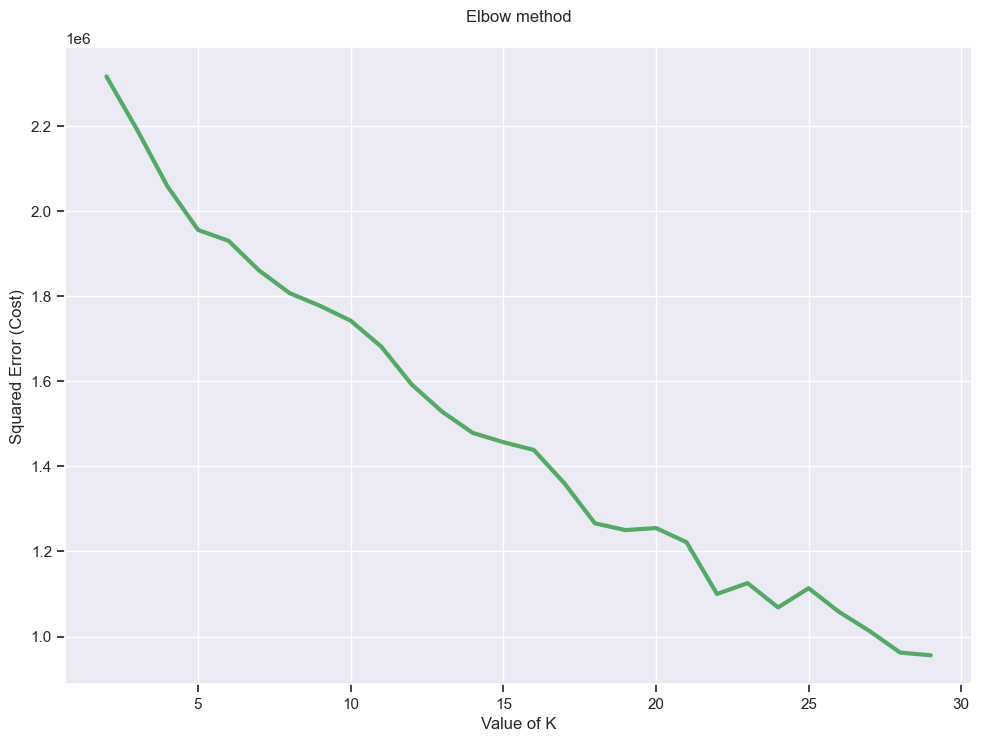

In [31]:
cost =[]
test_clusters = [i for i in range(2, 30)]
for i in test_clusters:
    #cls=KMeans(n_clusters=i,n_init=50,init='k-means++')
    cls = KMeans(n_clusters=i)
    cls.fit(X_std)
    cost.append(cls.inertia_)    


plt.plot(test_clusters, cost, color ='g', linewidth ='3')
plt.title("Elbow method\n")
plt.xlabel("Value of K")
plt.ylabel("Squared Error (Cost)")
#plt.axvline(x=nb_groupes_de_points, ymin=0, ymax=1, color="red")
plt.show()

In [43]:
# recherche nb optimum de clusters
## inertia = Sum of squared distances of samples to their closest cluster center

In [32]:
inertia = {}
dict_kmeans = {}
for k in range(1,25):
    print(k)
    kmeans = KMeans(n_clusters=k,
                   verbose=1,
                   random_state=0
                   ).fit(X_std)
    inertia[k] = kmeans.inertia_
    dict_kmeans[k] = kmeans

1
Initialization complete
Iteration 0, inertia 3265734.1532496144.
Iteration 1, inertia 2384975.0000000065.
Converged at iteration 1: strict convergence.
2
Initialization complete
Iteration 0, inertia 2746189.9189414894.
Iteration 1, inertia 2278347.9038832136.
Iteration 2, inertia 2239326.2886503544.
Iteration 3, inertia 2234202.4213412106.
Iteration 4, inertia 2234196.7544706548.
Converged at iteration 4: center shift 4.7743902467085794e-06 within tolerance 0.00010000000000001361.
3
Initialization complete
Iteration 0, inertia 2685662.847605114.
Iteration 1, inertia 2193602.8655058593.
Iteration 2, inertia 2153600.720184002.
Iteration 3, inertia 2148050.5437500793.
Iteration 4, inertia 2147786.40913012.
Iteration 5, inertia 2147733.952764608.
Iteration 6, inertia 2147725.5515317293.
Iteration 7, inertia 2147723.563981655.
Iteration 8, inertia 2147717.7412940613.
Iteration 9, inertia 2147692.9572982374.
Iteration 10, inertia 2147680.5305181006.
Iteration 11, inertia 2147679.812431833.

Initialization complete
Iteration 0, inertia 243214.89408849675.
Iteration 1, inertia 192974.05293852912.
Iteration 2, inertia 184903.71868142404.
Iteration 3, inertia 182061.18571834196.
Iteration 4, inertia 181324.56746084933.
Iteration 5, inertia 180991.43829068317.
Iteration 6, inertia 180812.82872179538.
Iteration 7, inertia 180656.86888479002.
Iteration 8, inertia 180499.01738610014.
Iteration 9, inertia 180395.0175989711.
Iteration 10, inertia 180337.11410740588.
Iteration 11, inertia 180299.93801210684.
Iteration 12, inertia 180266.8337601997.
Iteration 13, inertia 180241.55372019467.
Iteration 14, inertia 180226.35510373893.
Iteration 15, inertia 180220.1312170665.
Iteration 16, inertia 180216.79349286616.
Iteration 17, inertia 180215.19191162207.
Iteration 18, inertia 180213.61057930754.
Iteration 19, inertia 180212.43225780787.
Iteration 20, inertia 180211.58830879958.
Converged at iteration 20: center shift 5.5640563575243354e-05 within tolerance 9.999999999998735e-05.
22
I

<AxesSubplot:title={'center':'Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters'}>

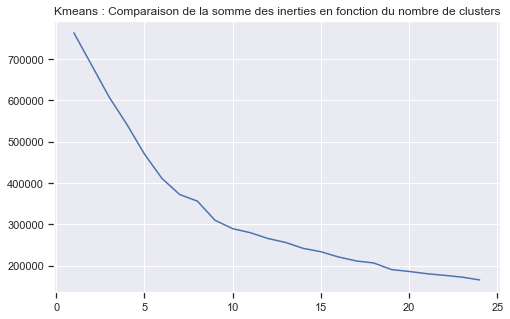

In [45]:
plt.figure(figsize=(8,5))
plt.title('Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters')
sns.lineplot(list(inertia.keys()),
             list(inertia.values())
            )


In [35]:
inertia = {}
dict_kmeans = {}

nb_boucles=3
max_clusters = 25

for k in range(1,nb_boucles+1):
    print('Boucle ',k)
    for i in range(1,max_clusters+1):
        kmeans = KMeans(n_clusters=i,
                       verbose=1,
                       #n_jobs=-1
                       ).fit(X_std)
        inertia[(k,i)] = kmeans.inertia_
        dict_kmeans[k,i] = kmeans

Boucle  1
Initialization complete
Iteration 0, inertia 3437753.1788874473.
Iteration 1, inertia 2384975.0000000065.
Converged at iteration 1: strict convergence.
Initialization complete
Iteration 0, inertia 4635770.939502225.
Iteration 1, inertia 2289849.080342202.
Iteration 2, inertia 2265131.2838378274.
Iteration 3, inertia 2230982.8043861035.
Iteration 4, inertia 2224749.3251736443.
Iteration 5, inertia 2224586.1354290736.
Converged at iteration 5: center shift 8.495088949035513e-05 within tolerance 0.00010000000000001361.
Initialization complete
Iteration 0, inertia 2910660.6455093287.
Iteration 1, inertia 2199409.295635426.
Iteration 2, inertia 2158666.7432208164.
Iteration 3, inertia 2111267.8658150653.
Iteration 4, inertia 2091972.8413212406.
Iteration 5, inertia 2091839.9079617192.
Iteration 6, inertia 2091835.6796653902.
Converged at iteration 6: center shift 1.522571949658083e-06 within tolerance 0.00010000000000001361.
Initialization complete
Iteration 0, inertia 2540991.998

Iteration 20, inertia 56460.86211502993.
Converged at iteration 20: strict convergence.
Initialization complete
Iteration 0, inertia 83948.06542593395.
Iteration 1, inertia 56352.478980545515.
Iteration 2, inertia 55552.68853953351.
Iteration 3, inertia 55277.86365246448.
Iteration 4, inertia 55040.17174671696.
Iteration 5, inertia 54812.47710143379.
Iteration 6, inertia 54565.5551952558.
Iteration 7, inertia 54334.42206161461.
Iteration 8, inertia 54239.0605919913.
Iteration 9, inertia 54195.04001377395.
Iteration 10, inertia 54168.065389213334.
Iteration 11, inertia 54154.861893139074.
Iteration 12, inertia 54145.437054019654.
Iteration 13, inertia 54138.08948846735.
Iteration 14, inertia 54132.95263948744.
Iteration 15, inertia 54127.58274693217.
Iteration 16, inertia 54114.877997959804.
Iteration 17, inertia 54093.02048662059.
Iteration 18, inertia 54059.003226745706.
Iteration 19, inertia 54012.66236655251.
Iteration 20, inertia 53913.653419074355.
Iteration 21, inertia 53706.0694

Iteration 0, inertia 54395.76259037549.
Iteration 1, inertia 37174.94151799836.
Iteration 2, inertia 36469.78704190371.
Iteration 3, inertia 36230.464670257614.
Iteration 4, inertia 36172.54313163688.
Iteration 5, inertia 36142.52864646783.
Iteration 6, inertia 36110.98365678836.
Iteration 7, inertia 36086.97341213866.
Iteration 8, inertia 36083.73783317379.
Iteration 9, inertia 36082.91057178985.
Iteration 10, inertia 36082.575913231616.
Iteration 11, inertia 36082.43687430932.
Iteration 12, inertia 36082.29497331299.
Iteration 13, inertia 36081.98598188341.
Iteration 14, inertia 36081.64277087267.
Iteration 15, inertia 36081.5432666069.
Converged at iteration 15: center shift 1.6484516643236188e-05 within tolerance 3.605966030769255e-05.
Initialization complete
Iteration 0, inertia 51442.484579713186.
Iteration 1, inertia 35592.42109391393.
Iteration 2, inertia 34987.78549092678.
Iteration 3, inertia 34774.043197479914.
Iteration 4, inertia 34618.386410444065.
Iteration 5, inertia 34

Iteration 0, inertia 49571.244838765764.
Iteration 1, inertia 33857.024438760556.
Iteration 2, inertia 32482.577752810175.
Iteration 3, inertia 31973.534595159435.
Iteration 4, inertia 31755.66020400391.
Iteration 5, inertia 31508.659737855567.
Iteration 6, inertia 31198.338821078614.
Iteration 7, inertia 30838.83491986686.
Iteration 8, inertia 30667.82146353678.
Iteration 9, inertia 30381.11649460908.
Iteration 10, inertia 30106.061516120277.
Iteration 11, inertia 29971.677510927442.
Iteration 12, inertia 29962.53599310407.
Iteration 13, inertia 29955.541476166618.
Iteration 14, inertia 29943.98496212732.
Iteration 15, inertia 29941.558090023987.
Iteration 16, inertia 29940.746562887165.
Iteration 17, inertia 29940.55163428188.
Iteration 18, inertia 29940.40570482332.
Iteration 19, inertia 29940.35933931968.
Iteration 20, inertia 29940.32911982026.
Converged at iteration 20: center shift 3.249503824876272e-05 within tolerance 3.605966030769255e-05.
Initialization complete
Iteration 0,

Iteration 0, inertia 73651.5312496192.
Iteration 1, inertia 50070.287229687456.
Iteration 2, inertia 49305.678456905356.
Iteration 3, inertia 49109.77759934149.
Iteration 4, inertia 48944.637102145454.
Iteration 5, inertia 48865.81359249083.
Iteration 6, inertia 48835.37589980018.
Iteration 7, inertia 48822.803439154784.
Iteration 8, inertia 48817.823951197905.
Iteration 9, inertia 48814.215123346745.
Iteration 10, inertia 48811.87093350178.
Iteration 11, inertia 48810.65912968383.
Iteration 12, inertia 48807.79453611134.
Iteration 13, inertia 48803.457251733445.
Iteration 14, inertia 48800.578059687294.
Iteration 15, inertia 48798.78350960177.
Iteration 16, inertia 48798.18043035808.
Iteration 17, inertia 48797.99923412284.
Converged at iteration 17: strict convergence.
Initialization complete
Iteration 0, inertia 65570.3187610987.
Iteration 1, inertia 48283.668617035306.
Iteration 2, inertia 46387.84940414285.
Iteration 3, inertia 45624.794169194334.
Iteration 4, inertia 45252.323626

Iteration 0, inertia 48739.5345115713.
Iteration 1, inertia 33603.45249295275.
Iteration 2, inertia 32702.653636989526.
Iteration 3, inertia 32430.070453546512.
Iteration 4, inertia 32371.03237867004.
Iteration 5, inertia 32338.921140043683.
Iteration 6, inertia 32265.21417173355.
Iteration 7, inertia 32095.195210593625.
Iteration 8, inertia 31951.152962478023.
Iteration 9, inertia 31922.922607876404.
Iteration 10, inertia 31914.060159862172.
Iteration 11, inertia 31912.589586121532.
Iteration 12, inertia 31911.57743016278.
Iteration 13, inertia 31911.150828198555.
Iteration 14, inertia 31910.934108574034.
Iteration 15, inertia 31910.760354887374.
Iteration 16, inertia 31910.4138141968.
Iteration 17, inertia 31910.350884798416.
Converged at iteration 17: strict convergence.
Initialization complete
Iteration 0, inertia 48656.41039456867.
Iteration 1, inertia 33959.310624687576.
Iteration 2, inertia 32715.257181660094.
Iteration 3, inertia 32339.01111591977.
Iteration 4, inertia 32146.43

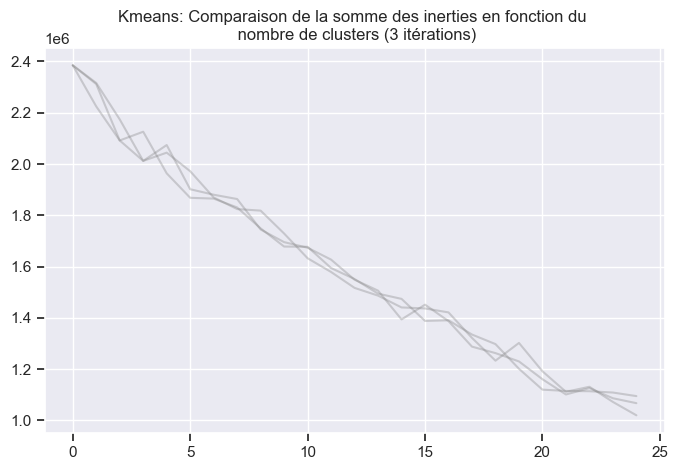

In [36]:
chaine = 'Kmeans: Comparaison de la somme des inerties en fonction du \n nombre de clusters (' + str(nb_boucles) + ' itérations)'
plt.figure(figsize=(8,5))
plt.title(chaine)
for i in range(0,nb_boucles):
    index_plot = [cluster+i*(max_clusters) for cluster in list(range(0,max_clusters))][0:max_clusters]
    sous_liste = [list(inertia.values())[index] for index in index_plot]
    sns.lineplot(list(range(0,max_clusters)),
                 sous_liste, alpha=1/nb_boucles, color='grey')

### coefficient de silhouette

In [37]:
silhouettes_kmeans = {}
max_clusters = 4
for i in range(2,max_clusters):
    sil_var = silhouette_score(
                                X = X_std,
                                labels= list(dict_kmeans[(1,i)].labels_))
    print(sil_var)
    #print(dict_kmeans[(1,i)].labels_)
    silhouettes_kmeans[i] = sil_var

0.1854370983865469
0.13013291958762224


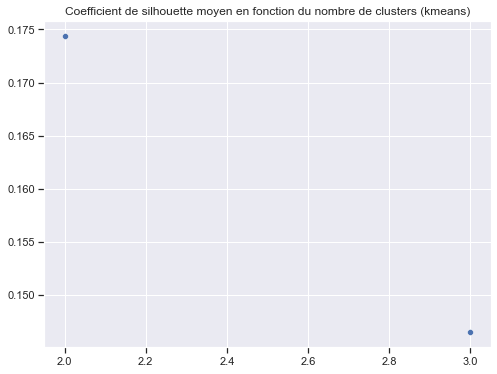

In [49]:
plt.figure(figsize=(8,6)),
plt.title('Coefficient de silhouette moyen en fonction du nombre de clusters (kmeans)')
sns.scatterplot(x = list(silhouettes_kmeans.keys()),
               y = list(silhouettes_kmeans.values()))
plt.show()

In [38]:
for key, value in silhouettes_kmeans.items():
    if value == max(silhouettes_kmeans.values()):
        print('le coefficient de silhouette est maximal pour {} clusters (score = {})'.format(key, value))
        nb_clusters = key

le coefficient de silhouette est maximal pour 2 clusters (score = 0.1854370983865469)


In [51]:
nb_clusters

2

### Model

In [39]:
kmeans = KMeans(n_clusters=3, 
                verbose=1, 
                random_state=0,
               #n_jobs=-1
               ).fit(X_std)

Initialization complete
Iteration 0, inertia 2685662.847605114.
Iteration 1, inertia 2193602.8655058593.
Iteration 2, inertia 2153600.720184002.
Iteration 3, inertia 2148050.5437500793.
Iteration 4, inertia 2147786.40913012.
Iteration 5, inertia 2147733.952764608.
Iteration 6, inertia 2147725.5515317293.
Iteration 7, inertia 2147723.563981655.
Iteration 8, inertia 2147717.7412940613.
Iteration 9, inertia 2147692.9572982374.
Iteration 10, inertia 2147680.5305181006.
Iteration 11, inertia 2147679.812431833.
Iteration 12, inertia 2147678.97652984.
Iteration 13, inertia 2147678.5662356406.
Converged at iteration 13: strict convergence.


In [55]:
kmeans.labels_

array([1, 0, 0, ..., 0, 0, 2])

In [ ]:
##wcss stands for within cluster sum of squares


#wcss={}

#for k in range(2,15):
#    km = KMeans(n_clusters=k, init='k-means++', max_iter=1000 , random_state=20)
#    km = km.fit(X)
#    wcss[k] = silhouette_score(X, km.labels_)
    
##Plot graph for the wcss values and the number of clusters

#sns.pointplot(x=list(wcss.keys()), y=list(wcss.values()))
#plt.xlabel('Number of clusters K')
#plt.ylabel('Sum of square distances')
#plt.title('Elbow method for optimal K')
#plt.show()

In [ ]:
# score de silhouette
#  sklearn.metrics.silhouette_score(X, labels, *, metric='euclidean', sample_size=None, random_state=None, **kwds)[source]

## T-SNE

In [48]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=0)

In [49]:
tsne_result = tsne.fit_transform(X_std)

In [50]:
tsne_result.shape

(95399, 2)

<AxesSubplot:title={'center':'Représentation de la séparation des données du DBSCAN via T-SNE'}>

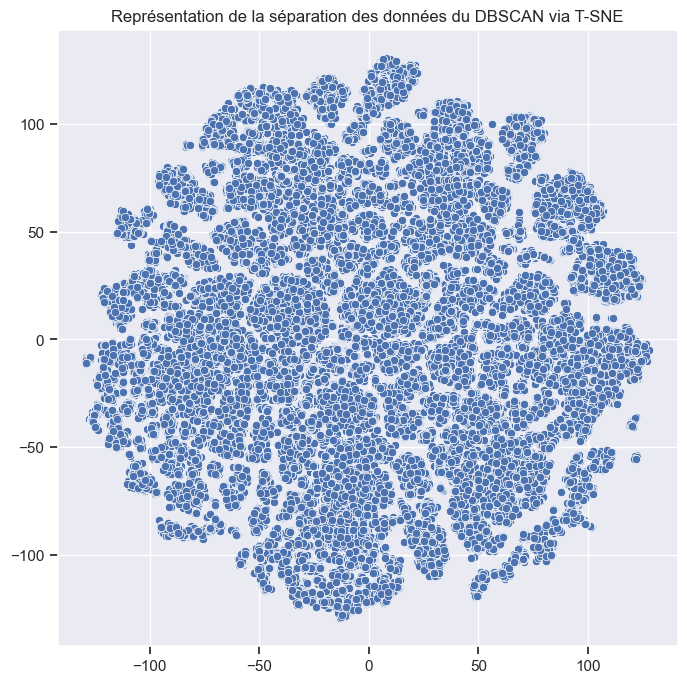

In [51]:
# Représentation via T-SNE
plt.figure(figsize=(8,8))
plt.title('Représentation de la séparation des données du DBSCAN via T-SNE')
sns.scatterplot(tsne_result[:,0], tsne_result[:,1])

# DBscan

In [53]:
dbs = DBSCAN(eps = 1, 
             min_samples=5,
               n_jobs=-1
            ).fit(X_std.copy())

In [54]:
dbs.labels_

array([-1,  0,  1, ...,  7, -1,  3], dtype=int64)

<AxesSubplot:title={'center':'Représentation de la séparation des données du DBSCAN via T-SNE'}>

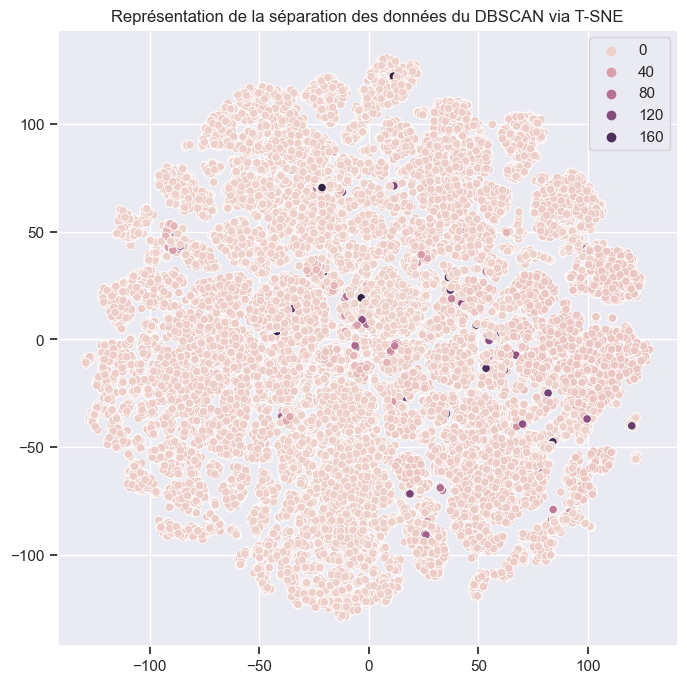

In [55]:
# Représentation via T-SNE
plt.figure(figsize=(8,8))
plt.title('Représentation de la séparation des données du DBSCAN via T-SNE')
sns.scatterplot(tsne_result[:,0], tsne_result[:,1], dbs.labels_)

In [43]:
# https://medium.com/@mohantysandip/a-step-by-step-approach-to-solve-dbscan-algorithms-by-tuning-its-hyper-parameters-93e693a91289
# silhouette to eps distance

# silhouette score gives the avg value for all the samples.
# this gives a perspective into the density and separation of the formed clusters

#range_eps = np.arange(0.1, 1.1, 0.1)
range_eps = np.arange(1, 10, 1)
range_eps

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [42]:
dict = {
    "eps_value" :[]
    ,"silhouette_avg" :[]
    }

for i in range_eps:
    #print("eps value is " +str(i))
    db= DBSCAN(eps=i, min_samples=5, n_jobs=-1).fit(X_std)
    core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
    core_samples_mask[db.core_sample_indices_] = True
    labels = db.labels_
    #print(set(labels))
    silhouette_avg = silhouette_score(X_std, labels)
    dict["eps_value"].append(i)
    dict["silhouette_avg"].append(silhouette_avg)
    #print("For eps value = "+str(i), labels,
    #      "The average silhouette_score is : ", silhouette_avg)

eps_df = pd.DataFrame.from_dict(dict)
eps_df.sort_values(by="silhouette_avg", ascending=False)

NameError: name 'range_eps' is not defined

In [115]:
eps_max_silhouette = float(eps_df.sort_values(by="silhouette_avg", ascending=False).head(1)['eps_value'])
eps_max_silhouette

7.0

In [101]:
# find the 'min_samples' hyper parameter through right cluster formation method

min_samples = np.arange(1, 11, 1)
min_samples

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [117]:
dict2 = {
    "min_sample_value" :[]
    ,"nb_clusters" :[]
    }

for i in min_samples:
    db= DBSCAN(eps=eps_max_silhouette, min_samples=i, n_jobs=-1).fit(X_enc)
    core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
    core_samples_mask[db.core_sample_indices_] = True
    # Ignoring the label '-1' as its for the outliers
    labels = set([label for label in db.labels_ if label >=0])
    dict2["min_sample_value"].append(i)
    dict2["nb_clusters"].append(str(len(set(labels))))
    #print("For eps value = "+str(i), labels,
    #      "The average silhouette_score is : ", silhouette_avg)

min_samples_df = pd.DataFrame.from_dict(dict2)
min_samples_df.sort_values(by="nb_clusters", ascending=False) 

,min_sample_value,nb_clusters
0,1,3
1,2,2
2,3,2
3,4,1
4,5,1
5,6,1
6,7,1
7,8,1
8,9,1
9,10,1


In [146]:
### compute DBSCAN with new values :
dbs_2 = DBSCAN(eps= 2, 
             min_samples= 7,
               n_jobs= -1
            ).fit(X_enc.copy())
dbs_2.labels_

array([ 0,  1,  2, ..., -1,  2,  3], dtype=int64)

<AxesSubplot:title={'center':'Représentation de la séparation des données du DBSCAN via T-SNE'}>

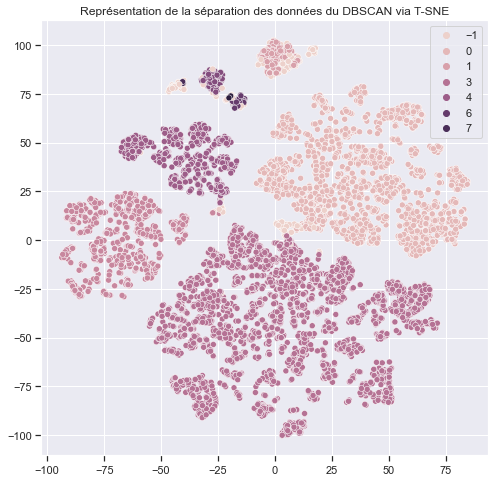

In [147]:
# Représentation via T-SNE
plt.figure(figsize=(8,8))
plt.title('Représentation de la séparation des données du DBSCAN via T-SNE')
sns.scatterplot(tsne_result[:,0], tsne_result[:,1], dbs_2.labels_)

## SMOTE-NC

In [52]:
# https://medium.com/analytics-vidhya/smote-nc-in-ml-categorization-models-fo-imbalanced-datasets-8adbdcf08c25

### Clustering hiérarchique

In [ ]:
nb_clusters_agg = nb_clusters

In [ ]:
cah = AgglomerativeClustering(n_clusters = nb_clusters_agg
                             ).fit(X.copy())


In [47]:
graph = pd.DataFrame(data = [T[:,0], T[:,1], dict_kmeans[(1,11)].labels_]).T
graph.columns = ['X', 'Y', 'label_kmeans']

In [48]:
graph['x_pca'] = x_show
graph['y_pca'] = y_show
graph['z_pca'] = z_show

NameError: name 'x_show' is not defined

In [ ]:
graph

In [ ]:
plt.figure(figsize=(10,10))
plt.title('Représentation de la séparation des données du CAH via T-SNE')
sns.scatterplot(graph['X'], 
                graph['Y'], 
                hue = cah.labels_, 
                legend='full',
               palette=sns.color_palette("hls",nb_clusters_agg))
plt.legend(loc='upper left', labels=graph['label_kmeans'].unique())
plt.show()

In [ ]:
## ne pas utiliser PCA (permet de voir cassure) => focus TSNE (x y z)
## dbscan sur 3
# visualisation : tsne + labels/couleurs, scatterplot
# /!\ scaling / encoding données : dans la préparation des données, modelisation = modeles uniquement

In [ ]:
# ajouter features
# chercher meilleur parametrage 
# pour kmeans et pour dbscan
# /!\ responsable pédagogique